# **I. INTRODUCTION**

* **Name :** Daniel Christopher Miarsa

* **Objective:** This program predicts whether a transaction on Ethereum blockchain is fraudulent or safe. KNN, SVM, Decision Tree, Random Forest, and XGBoost will be used to determine the most optimum model in detecting fraud transactions.

* **Target users:** Active traders, blockchain validators, or CEXs / DEXs QA team.


***Dataset :***

[Ethereum Fraud Detection (2019)]('https://www.kaggle.com/datasets/vagifa/ethereum-frauddetection-dataset')

The author collected the data from [Etherscan](https://etherscan.io/) up to 2019

***Background :***

> Crypto currencies have been growing rapidly after Covid-19 pandemic. Many people, investors, and even instituion start to believe and take part in developing, exploring, and utilizing the blockchain technology. However, the cyber security risk in this industry is inevitable. According to [Chainanalysis (2024)]('https://www.chainalysis.com/blog/crypto-hacking-stolen-funds-2025/'), total funds stolen in 2024 alone was $2.2 Billion and total hacking incidents recorded in 2024 were 303 cases. Moreover, earlier this year, Bybit (Centralized Exchange) suffered a 400,000 ETH (~ $1.4 Billion) loss from a single hacking case by North Korean hackers, making this incident the largest single theft in the crypto industry's history [(Crystal Intelligence, 2025)]('https://crystalintelligence.com/investigations/the-10-biggest-crypto-hacks-in-history/').

***Problem Statement :***
> Reducing fraud transactions on Ethereum blockchain by 15% through preventive transaction protocols based on the ML supervised prediction model in the next 6 months.


# **II. IMPORT LIBRARIES**

In [10]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import phik

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from feature_engine.outliers import Winsorizer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA

# Model Libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Eval metrics
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.model_selection import RandomizedSearchCV

import pickle
import json

import warnings
warnings.filterwarnings("ignore")

# **III. DATA LOADING**

In [11]:
# load dataframe
df = pd.read_csv('transaction_dataset.csv')
df.head(10)

,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS
5,5,6,0x000895ad78f4403ecd9468900e68d6ee506136fd,0,9900.12,375.48,20926.68,2,3,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0,0
6,6,7,0x000d63fc5df52b0204374c2f5a3249779805d5d1,0,69.46,629.44,8660.35,25,11,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0,0
7,7,8,0x000e001ab444fa8d6dc4a402f8d7cfc88fe8c64d,0,1497.39,176.84,319828.05,213,5,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,7.0,NaN,XENON
8,8,9,0x0012cb699c836049a4bbeaac2d8c4d47c688e0e4,0,0.00,0.00,496.62,1,1,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0,0
9,9,10,0x0012f247c9f980eea0a9ad06893bfd95c3145794,0,2570.59,3336.01,30572.70,8,3,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,1.0,NaN,AICRYPTO


In [12]:
# Remove index & unnamed cols

df = df.drop(columns=['Unnamed: 0','Index'])
df.head(10)

,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,40,118,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,5,14,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,10,2,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,7,13,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,7,19,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS
5,0x000895ad78f4403ecd9468900e68d6ee506136fd,0,9900.12,375.48,20926.68,2,3,0,2,1,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0,0
6,0x000d63fc5df52b0204374c2f5a3249779805d5d1,0,69.46,629.44,8660.35,25,11,0,9,20,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0,0
7,0x000e001ab444fa8d6dc4a402f8d7cfc88fe8c64d,0,1497.39,176.84,319828.05,213,5,0,3,3,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,7.0,NaN,XENON
8,0x0012cb699c836049a4bbeaac2d8c4d47c688e0e4,0,0.00,0.00,496.62,1,1,0,1,1,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0,0
9,0x0012f247c9f980eea0a9ad06893bfd95c3145794,0,2570.59,3336.01,30572.70,8,3,0,2,4,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,1.0,NaN,AICRYPTO


In [13]:
# Check duplicates entries
df.duplicated().sum()

np.int64(18)

There are 18 duplicate rows in the dataset

In [14]:
# Drop duplicates
df.drop_duplicates(ignore_index=True, inplace=True)

In [15]:
# General Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9823 entries, 0 to 9822
Data columns (total 49 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Address                                               9823 non-null   object 
 1   FLAG                                                  9823 non-null   int64  
 2   Avg min between sent tnx                              9823 non-null   float64
 3   Avg min between received tnx                          9823 non-null   float64
 4   Time Diff between first and last (Mins)               9823 non-null   float64
 5   Sent tnx                                              9823 non-null   int64  
 6   Received Tnx                                          9823 non-null   int64  
 7   Number of Created Contracts                           9823 non-null   int64  
 8   Unique Received From Addresses                        9823

- This data has 9823 rows and 49 columns

- All columns dtypes are already in the required type

- Apart from the target column, there are only 2 categorical features in this dataframe (`ERC20 most sent token type` & `ERC20_most_rec_token_type`)

- Starting from column `Total ERC20 tnxs` to `ERC20 uniq rec token name`, the number of total missing values remain the same. Those columns might be related to one another.

- The last 2 columns (`ERC20 most sent token type` & `ERC20_most_rec_token_type`) show higher missing entries compared to the other columns

- There are whitespaces in the column names

In [16]:
# Removing whitespaces
df.columns = df.columns.str.strip()

In [17]:
# Count total missing values
print(df[df.isnull().any(axis=1)].shape[0])
print(df[df.isnull().any(axis=1)].shape[0]*100/len(df))

2717
27.659574468085108


There are 2717 missing rows in this data, accounting for 27.66% of the total entries.

In [18]:
# Check unique values for categorical columns
df.iloc[:, -2:].nunique()

ERC20 most sent token type    304
ERC20_most_rec_token_type     466
dtype: int64

The categorical columns have high cardinality

# **IV. EXPLORATORY DATA ANALYSIS (EDA)**

## **Data Summary**

In [19]:
# Overall statistical summary 
df.iloc[:,[2,3,8,9,10,11,12,13,14,15]].describe()

,Avg min between sent tnx,Avg min between received tnx,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,avg val received,min val sent,max val sent,avg val sent
count,9823.000000,9823.000000,9823.000000,9823.000000,9823.000000,9823.000000,9823.000000,9823.000000,9823.000000,9823.000000
mean,5092.595652,8011.602499,30.406495,25.868472,43.785903,523.692459,100.638887,4.806480,314.528353,44.638924
std,21505.395360,23097.130771,298.892226,264.058187,326.137833,13020.716151,2887.614225,138.736510,6635.215478,239.127317
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,1.000000,0.001000,1.000000,0.424921,0.000000,0.160818,0.085688
50%,17.340000,513.420000,2.000000,2.000000,0.095006,6.000000,1.724272,0.049139,4.999276,1.599475
75%,564.305000,5494.510000,5.000000,3.000000,2.000000,66.992806,22.000000,0.998800,61.337946,21.999380
max,430287.670000,482175.490000,9999.000000,9287.000000,10000.000000,800000.000000,283618.831600,12000.000000,520000.000000,12000.000000


Based on users' transaction frequency behaviour (`Avg min between sent tnx` & `Avg min between received tnx`), ***on average*** :

- Users are likely to **SEND** their crypto to different wallet address every 5092.6 minutes (3 - 4 days)

- Users are likely to **RECEIVE** crypto from different wallet address every 8011.6 minutes (5 - 6 days)

Based on total interaction with different addresses (`Unique Received From Addresses` & `Unique Sent To Addresses`), ***on average*** :

- Each user is likely to **RECEIVE** crypto currencies from 30 wallets, and

- Each user is likely to **SEND** crypto currencies to 25 - 26 wallets

In a single **RECEIVE** transaction, users may receive from 43.8 ETH - 523.7 ETH ($132,000 - $1,580,000), but on average, they usually receive 100.6 ETH ($304,000).

In a single **SENT** transaction, users may spend from 4.8 ETH - 314.5 ETH ($14,500 - $950,000), with the average spending approximately at 44.6 ETH ($135,000).


In [20]:
# ETH & ERC-20 Transaction by Wallet Address (user) Summary
df.iloc[:, 20:28].describe()

,total Ether sent,total ether received,total ether sent contracts,total ether balance,Total ERC20 tnxs,ERC20 total Ether received,ERC20 total ether sent,ERC20 total Ether sent contract
count,9.823000e+03,9.823000e+03,9823.000000,9.823000e+03,8994.000000,8.994000e+03,8.994000e+03,8994.000000
mean,1.017806e+04,1.165818e+04,0.000008,1.480124e+03,36.292751,1.298795e+08,1.389373e+07,111.161233
std,3.586507e+05,3.645380e+05,0.000516,2.426474e+05,447.965241,1.054912e+10,1.181571e+09,6134.763281
min,0.000000e+00,0.000000e+00,0.000000,-1.560535e+07,0.000000,0.000000e+00,0.000000e+00,0.000000
25%,2.251911e-01,2.674521e+00,0.000000,6.207450e-04,0.000000,0.000000e+00,0.000000e+00,0.000000
50%,1.244669e+01,3.050000e+01,0.000000,1.722000e-03,1.000000,1.000000e-12,0.000000e+00,0.000000
75%,1.009990e+02,1.010000e+02,0.000000,4.473055e-02,3.000000,1.003370e+02,0.000000e+00,0.000000
max,2.858096e+07,2.858159e+07,0.046029,1.428864e+07,10001.000000,1.000020e+12,1.120000e+11,416000.000000


***ETH Transaction:***
- On average, each wallet address has sent 10,178 ETH ($30 Million) & has received 11,658 ETH ($35 Million) cummulatively

- `total ether sent contracts` column max value is 0.046 ETH ($138), meaning only few users have interacted directly with the smart contract (votes, token swap, DeFi, NFTs, or DEX transaction)

`Total ether balance` = `total ether received` - `total Ether sent`
> - The average users' balance is 1,480 ETH ($4.45 Million)
> 
> - User Balance < 0 --> indicating ETH spent > ETH received --> might be a consideration of fraud



***ERC-20 Transaction:***

***Notes:***
> - [ERC 20 Tokens](https://etherscan.io/tokens) are smart-contract based tokens that are built on Ethereum Layers (e.g. USDT, BNB, USDC, LINK, SHIB, etc.). 
> - All ERC20 columns are measured in ETH equivalent.

The average `ERC20 total Ether received` & `ERC20 total ether sent` are 129.8 million ETH ($390 Billion) and 13.9 million ETH ($41.8 Billion), respectively. This might indicates there are some "Sharks" or "Whales" or other group of people with huge size that are actively trading altcoins besides the ETH native tokens.

If we compare it with the Q2(50%) and Q3(75%) values, most users don't recieve or sent any ERC20 Tokens. Based on `Total ERC20 tnxs`, majority of users have only made 1 - 3 transactions so far, while the maximum transactions have been made is 10,001 transactions from a single wallet address. This indicates only few users that are actively trading ERC20 tokens and some of them are considered as the "early adopters" because, as of 2019, there had only been 2 Bitcoin halvings.

<Axes: >

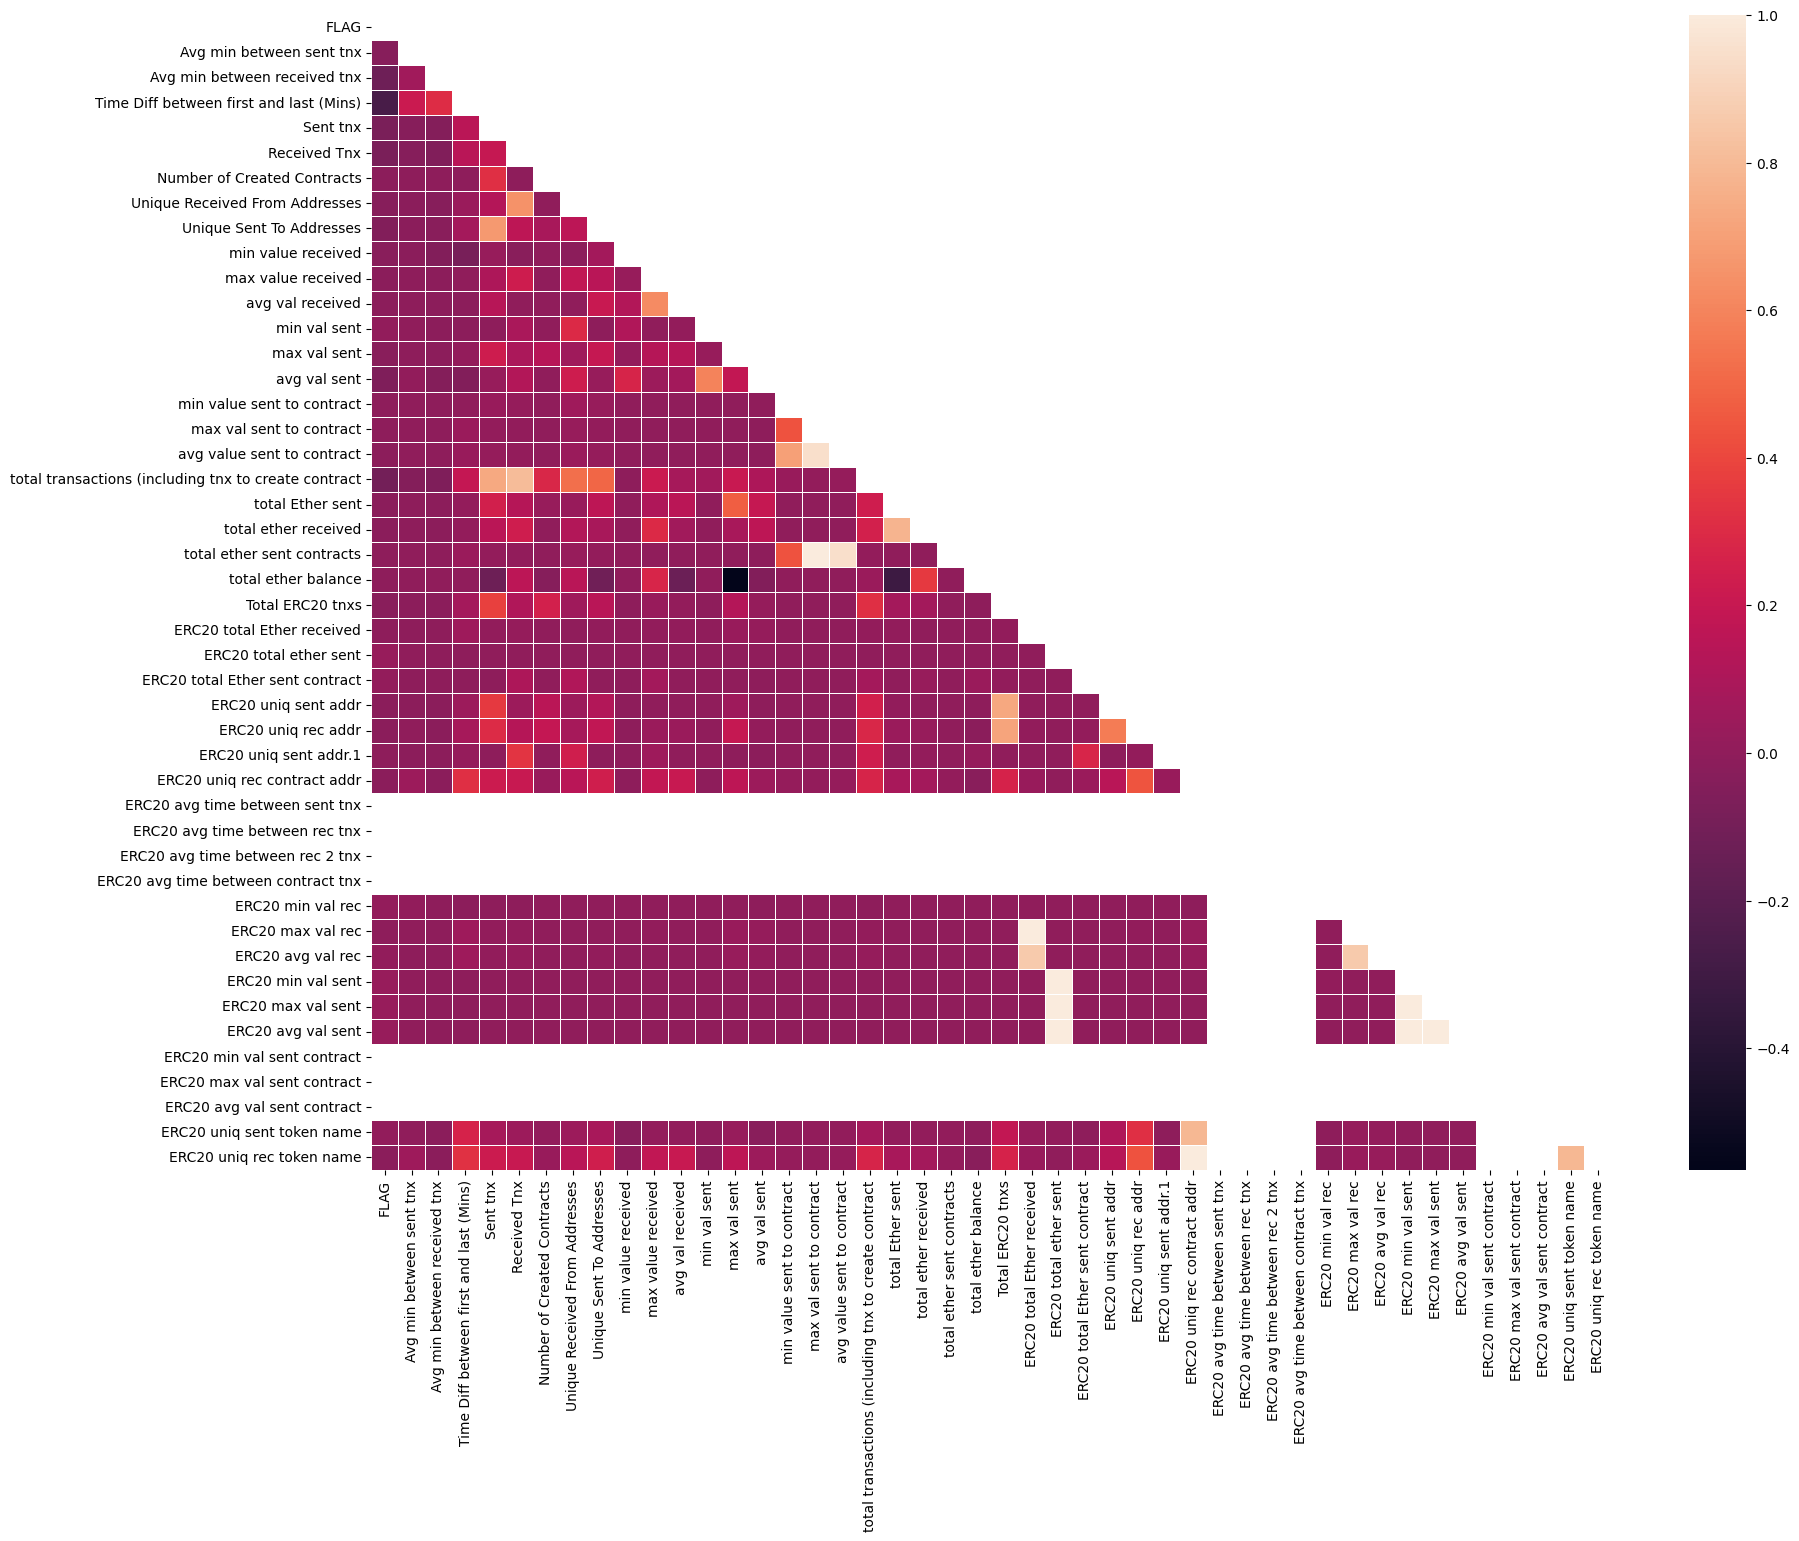

In [21]:
# Correlation
plt.figure(figsize=(20,15))
mask = np.triu(np.ones_like(df.drop(columns=['Address', 'ERC20 most sent token type', 'ERC20_most_rec_token_type']).corr(), dtype=bool))
sns.heatmap(df.drop(columns=['Address', 'ERC20 most sent token type', 'ERC20_most_rec_token_type']).corr(), mask=mask, linewidth=0.5)

According to the heatmap, there is multicolinearity among features. `total transactions (including tnx to create contract` & `total sent ether contracts` are the examples of features that might have high `VIF value` beacuse they correlates with multiple features. This issue will be handled in Feature Selection process.

There are some columns with white color:
- `ERC20 avg time between sent tnx`
- `ERC20 avg time between rec tnx`
- `ERC20 avg time between rec2 tnx`
- `ERC20 avg time between contract tnx`
- `ERC20 min val sent contract`
- `ERC20 max val sent contract`
- `ERC20 avg val sent contract`

These features might have an anomaly data value that make them highly correlated with all features. This issue will be handled in the feature engineering process.

## **Most Transfered ERC-20 Tokens**

In [22]:
# Check unique value in the categorical cols
for i in df.columns[-2:]:
    print(df[i].unique(),'\n')

['Cofoundit' 'Livepeer Token' nan 'Raiden' 'StatusNetwork' '0' 'TenXPay'
 'blockwell.ai KYC Casper Token' 'EOS' 'ICO' 'bitqy' 'OmiseGO' 'SONM'
 'BAT' 'Melon' 'Friendz Coin' 'FunFair' 'MKR' 'Golem' 'AION' 'Aragon'
 'TokenCard' 'Crypto.com' 'CRYPTOPUNKS' 'Aigang' 'Bancor' 'ZRX'
 'PangeaCoinICO' 'VeChain' 'Decentraland' 'Mysterium' 'Dochain'
 'SwarmCity' 'BNB' 'Humaniq' 'DGD' 'Storm' 'Patientory' 'NapoleonX'
 'Nexium' 'Qtum' 'district0x' 'Bytom' 'Identity Hub Token' 'Celsius'
 'Reputation' 'Tronix' 'ViteToken' 'Poker Chips' 'MEX' 'Salt' 'Edgeless'
 'SAN' 'TheDAO' 'Telcoin' 'EduCoin' 'DICE' 'Trustcoin' 'Tokenomy'
 'Veritaseum' 'Time New Bank' 'NimiqNetwork' 'Kin' 'UG Token' 'SNGLS'
 'BlockchainPoland' 'Monetha' 'Propy' 'Republic' 'Civic' 'Storj' 'Loom'
 'DATAcoin' 'ChainLink Token' 'Ether Token' 'Guaranteed Entrance Token'
 'Individual Content &amp; Skill Token' 'OWN' 'Populous' 'Sether'
 'Soarcoin' 'AdBank' 'Stox' 'FinShi Capital Tokens' 'Dao.Casino'
 'iXledger' 'Aeternity' 'TAAS' 'XENON'

In [23]:
# Filter null, empty, & '0' values

a = df.iloc[:, -2:].dropna()
a_filtered = a[~(a.iloc[:,-2:].isin([' ','0','', "''"]).any(axis=1))]

a_filtered

,ERC20 most sent token type,ERC20_most_rec_token_type
0,Cofoundit,Numeraire
1,Livepeer Token,Livepeer Token
3,Raiden,XENON
4,StatusNetwork,EOS
14,TenXPay,KyberNetwork
...,...,...
9729,Tronix,Tronix
9747,TenXPay,TenXPay
9795,XENON,Cryptonex
9806,blockwell.ai KYC Casper Token,ERC20


In [24]:
# Filter top 10 most popular ERC-20 Tokens
a_0 = a_filtered.iloc[:,0].value_counts().head(10)
a_1 = a_filtered.iloc[:,1].value_counts().head(10)

In [25]:
a_0

ERC20 most sent token type
EOS                              138
OmiseGO                          133
Golem                            129
blockwell.ai KYC Casper Token     96
StatusNetwork                     61
BAT                               38
Qtum                              34
Bancor                            31
Reputation                        26
Tronix                            26
Name: count, dtype: int64

In [26]:
a_1

ERC20_most_rec_token_type
EOS              157
OmiseGO          125
Golem            113
KickCoin          43
StatusNetwork     41
BAT               33
Tronix            32
Reputation        31
XENON             29
DATAcoin          25
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='ERC20_most_rec_token_type'>

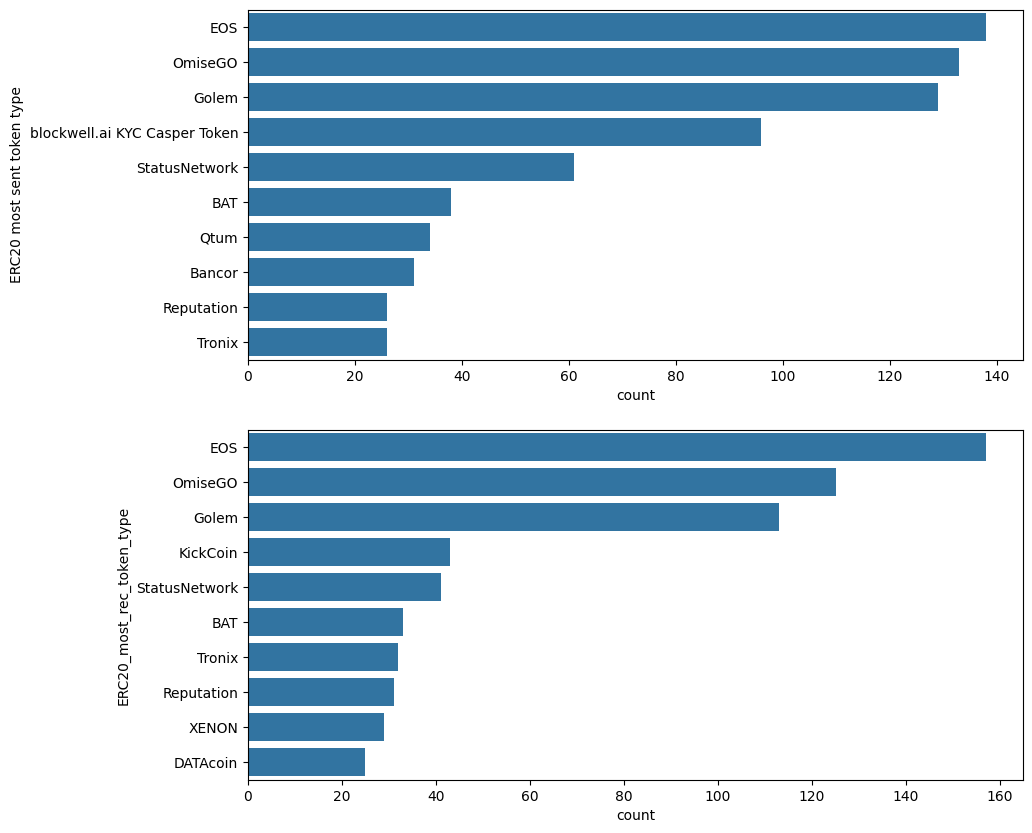

In [27]:
# Plot the distribution
fig, ax = plt.subplots(2,1, figsize=(10,10))
sns.barplot(data=a_0,orient='h',ax=ax[0])
sns.barplot(data=a_1,orient='h',ax=ax[1])

The top 3 most popular ERC-20 tokens `SENT` and `RECEIVED` are EOS, OmiseGO, and Golem 

Most ERC-20 tokens `SENT`:
- blokcwell.ai KYC Casper Token
- Status Network ($SNT)
- Basic Attention ($BAT)
- Qtum ($QTUM)
- Bancor Network ($BNT)
- Reputation ($REPV2)
- Tronix 

Most ERC-20 tokens `RECEIVED`:
- Kick Coin ($KICK)
- Status Network ($SNT)
- Basic Attention ($BAT)
- Tronix
- Reputation ($REPV2)
- Xenon ($XNN)
- DATAcoin ($DTC)

## **Tokens Prone to Fraud**

In [28]:
# Filtering all FRAUD rows with no null & empty values
fraud_df = df[(~(df.dropna().iloc[:,-2:].isin([' ','0','', "''"]).any(axis=1))) & (df.FLAG == 1)]
fraud_df

,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
7647,0x0059b14e35dab1b4eee1e2926c7a5660da66f747,1,2300.37,65.10,73091.00,29,98,0,89,26,...,0.000000,81324.074600,5232.816018,0.0,0.0,0.0,22.0,37.0,OCoin,OCoin
7654,0x00e01a648ff41346cdeb873182383333d2184dd1,1,28504.65,104.43,429867.15,15,22,0,21,13,...,0.000000,208.735045,69.578350,0.0,0.0,0.0,3.0,30.0,Civic,Ethos
7672,0x03b70dc31abf9cf6c1cf80bfeeb322e8d3dbb4ca,1,3545.11,8300.42,341014.55,40,24,0,21,28,...,37492.163260,37492.163260,37492.163260,0.0,0.0,0.0,1.0,1.0,Fortecoin,Fortecoin
7676,0x043375ebc36fff7a4fcef1359f3c89afddf56e08,1,5714.26,1151.26,91554.32,13,15,0,12,6,...,2299.528464,2299.528464,2299.528464,0.0,0.0,0.0,1.0,2.0,Vezt,Blockwell say NOTSAFU
7679,0x049b01966f721db6ec76097043e9d6eccaf719b6,1,13251.47,8664.00,280824.52,14,11,0,10,11,...,7301.960000,600000.000000,303650.980000,0.0,0.0,0.0,2.0,7.0,Merculet,Merculet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9729,0xf4c87c851d772b0f9e72cca0690327f2bc505015,1,13674.70,1198.99,279489.03,20,5,0,4,4,...,0.000000,1394.717021,228.024554,0.0,0.0,0.0,3.0,9.0,Tronix,Tronix
9747,0xf73ef0650415656b51be39bd5d37cf5ce03f4033,1,129.82,0.00,259.63,2,1,0,1,1,...,5000.000000,16000.000000,10500.000000,0.0,0.0,0.0,1.0,1.0,TenXPay,TenXPay
9795,0xfbf6f29c126382cf15795bb209ee506a174cc709,1,52366.67,426.30,279311.72,5,41,0,41,5,...,72.360080,13674.162000,5214.672963,0.0,0.0,0.0,3.0,10.0,XENON,Cryptonex
9806,0xfd8999b60a72c51ea892db66f5ef0c58f2ecd6d3,1,0.00,710.21,148350.08,1,8,0,8,1,...,100.000000,100.000000,100.000000,0.0,0.0,0.0,1.0,1.0,blockwell.ai KYC Casper Token,ERC20


In [29]:
# Check frequency
for i in fraud_df.columns[-2:]:
    print(fraud_df[i].value_counts().head(10),'\n')

ERC20 most sent token type
Tronix                           14
blockwell.ai KYC Casper Token    13
OmiseGO                           7
VeChain                           5
TenXPay                           5
Golem                             4
EOS                               3
AdEx                              3
Livepeer Token                    3
XENON                             3
Name: count, dtype: int64 

ERC20_most_rec_token_type
Blockwell say NOTSAFU               12
Tronix                              12
OmiseGO                             10
KickCoin                             5
Free BOB Tokens - BobsRepair.com     5
FunFair                              5
TenXPay                              4
Golem                                4
GSENetwork                           3
XENON                                3
Name: count, dtype: int64 



Tronix, Blockwell, and OmiseGO are the top 3 tokens that are prone to fraudulent transactions.

# **V. FEATURE ENGINEERING**

In [32]:
# Save a copy
df_copy = df.copy()

# Split X & y
y = df_copy.pop('FLAG')
X = df_copy

# Show the first 5 data in X 
X.head()

,Address,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,844.26,1093.71,704785.63,721,89,0,40,118,0.000000,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,0x0002b44ddb1476db43c868bd494422ee4c136fed,12709.07,2958.44,1218216.73,94,8,0,5,14,0.000000,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,0x0002bda54cb772d040f779e88eb453cac0daa244,246194.54,2434.02,516729.30,2,10,0,10,2,0.113119,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,10219.60,15785.09,397555.90,25,9,0,7,13,0.000000,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,36.61,10707.77,382472.42,4598,20,1,7,19,0.000000,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


In [33]:
y.value_counts()

FLAG
0    7644
1    2179
Name: count, dtype: int64

In [34]:
# Show the first 5 data in y
y.head()

0    0
1    0
2    0
3    0
4    0
Name: FLAG, dtype: int64

In [35]:
# Split Numerical & Catcols
cat_cols = X.columns[-2:].to_list()
num_cols = X.columns[1:-2].to_list() # Excluding Address column

## **Cardinality Handling**

In [36]:
# Check `ERC20 most sent token type` unique values	
X.iloc[:,-2].unique()

array(['Cofoundit', 'Livepeer Token', nan, 'Raiden', 'StatusNetwork', '0',
       'TenXPay', 'blockwell.ai KYC Casper Token', 'EOS', 'ICO', 'bitqy',
       'OmiseGO', 'SONM', 'BAT', 'Melon', 'Friendz Coin', 'FunFair',
       'MKR', 'Golem', 'AION', 'Aragon', 'TokenCard', 'Crypto.com',
       'CRYPTOPUNKS', 'Aigang', 'Bancor', 'ZRX', 'PangeaCoinICO',
       'VeChain', 'Decentraland', 'Mysterium', 'Dochain', 'SwarmCity',
       'BNB', 'Humaniq', 'DGD', 'Storm', 'Patientory', 'NapoleonX',
       'Nexium', 'Qtum', 'district0x', 'Bytom', 'Identity Hub Token',
       'Celsius', 'Reputation', 'Tronix', 'ViteToken', 'Poker Chips',
       'MEX', 'Salt', 'Edgeless', 'SAN', 'TheDAO', 'Telcoin', 'EduCoin',
       'DICE', 'Trustcoin', 'Tokenomy', 'Veritaseum', 'Time New Bank',
       'NimiqNetwork', 'Kin', 'UG Token', 'SNGLS', 'BlockchainPoland',
       'Monetha', 'Propy', 'Republic', 'Civic', 'Storj', 'Loom',
       'DATAcoin', 'ChainLink Token', 'Ether Token',
       'Guaranteed Entrance Token',


In [37]:
# Check `ERC20 most rec token type` unique values	
X.iloc[:,-1].unique()

array(['Numeraire', 'Livepeer Token', 'XENON', 'EOS', '0', 'AICRYPTO',
       'DATAcoin', 'PoSToken', 'KyberNetwork', nan, 'Bancor', 'OmiseGO',
       'ONOT', 'Tronix', 'StatusNetwork',
       'SAFE.AD - 20% DISCOUNT UNTIL 1 MAY', 'Storj', 'bitqy',
       'Beauty Coin', 'SONM', 'NEVERDIE', 'INS Promo', 'TenXPay',
       'Cybereits Token', 'FunFair', 'DGD', 'iEx.ec Network Token',
       'AION', 'Aragon', 'Cofoundit', 'Golem', 'CRYPTOPUNKS', 'Nitro',
       'Ether Token', 'VeChain', 'Reputation', 'Intelion', 'Dochain',
       'SwarmCity', 'BAT', 'LockTrip', 'Humaniq', 'KickCoin', 'BOX Token',
       'MobileGo', 'Monaco', 'Azbit', 'Nexium', 'ZGC', 'www.pnztrust.com',
       'Send your ETH to this contract and earn 2.55% every day for Live-long. https://255eth.club',
       'empowr', 'An Etheal Promo', 'BitClave', 'Bytom',
       'Identity Hub Token', 'Celsius', 'Raiden', 'Trustcoin', 'ARP',
       'Qtum', 'Poker Chips', 'Loopring', 'Penta Network Token', 'Salt',
       'ICONOMI', 'Edgele

In [38]:
# Check every value that might have empty string
for i in X.iloc[:,-2].unique():
    if len(str(i)) < 3:
        print(i)

0

 
''


In [39]:
# Check every value that might have empty string
for i in X.iloc[:,-1].unique():
    if len(str(i)) < 3:
        print(i)

0
 



In both categorical columns, the empty string values are `'0'`, `' '`,`''`, `"''"`. These values need to be assign as `None`.

In [40]:
# Rename all empty values into None
for col in cat_cols:
    X.loc[(X.iloc[:,-2:].isin([' ','0','', "''"]).any(axis=1)), col] = None

Now, we need to group all categorical values based on their frequency. For the categories below the top 10, will be grouped as 'Others'.

In [41]:
# Check frequency
for i in cat_cols:
    print(X[i].value_counts().head(10), '\n')

ERC20 most sent token type
EOS                              138
OmiseGO                          136
Golem                            129
blockwell.ai KYC Casper Token    108
StatusNetwork                     61
BAT                               38
Qtum                              34
Bancor                            32
Reputation                        26
Tronix                            26
Name: count, dtype: int64 

ERC20_most_rec_token_type
OmiseGO                          870
Blockwell say NOTSAFU            779
DATAcoin                         358
Livepeer Token                   205
EOS                              161
XENON                            145
Golem                            126
GSENetwork                        80
Tronix                            76
blockwell.ai KYC Casper Token     65
Name: count, dtype: int64 



In [42]:
# Sent token name index
sent_token_name = X.iloc[:,-2].value_counts().head(10).index.to_list()
sent_token_name += [None] # Excluding missing value

# Receive token name index
rec_token_name = X.iloc[:,-1].value_counts().head(10).index.to_list()
rec_token_name += [None] # Excluding missing value

In [43]:
# Define a function for cardinality handling
def cardinal_handle(col, token_index):
    
    # Assign 'Others' into the df
    X.loc[~(X.loc[:, col].isin(token_index)), col] = 'Others'

    return X[col]

In [44]:
# Apply to `ERC20 most sent token type`
cardinal_handle(cat_cols[0],sent_token_name)

0              Others
1              Others
2              Others
3              Others
4       StatusNetwork
            ...      
9818             None
9819             None
9820             None
9821           Others
9822             None
Name: ERC20 most sent token type, Length: 9823, dtype: object

In [45]:
# Apply to `ERC20_most_rec_token_type`
cardinal_handle(cat_cols[1],rec_token_name)

0                      Others
1              Livepeer Token
2                       XENON
3                       XENON
4                         EOS
                ...          
9818               GSENetwork
9819    Blockwell say NOTSAFU
9820                   Others
9821                   Others
9822                   Others
Name: ERC20_most_rec_token_type, Length: 9823, dtype: object

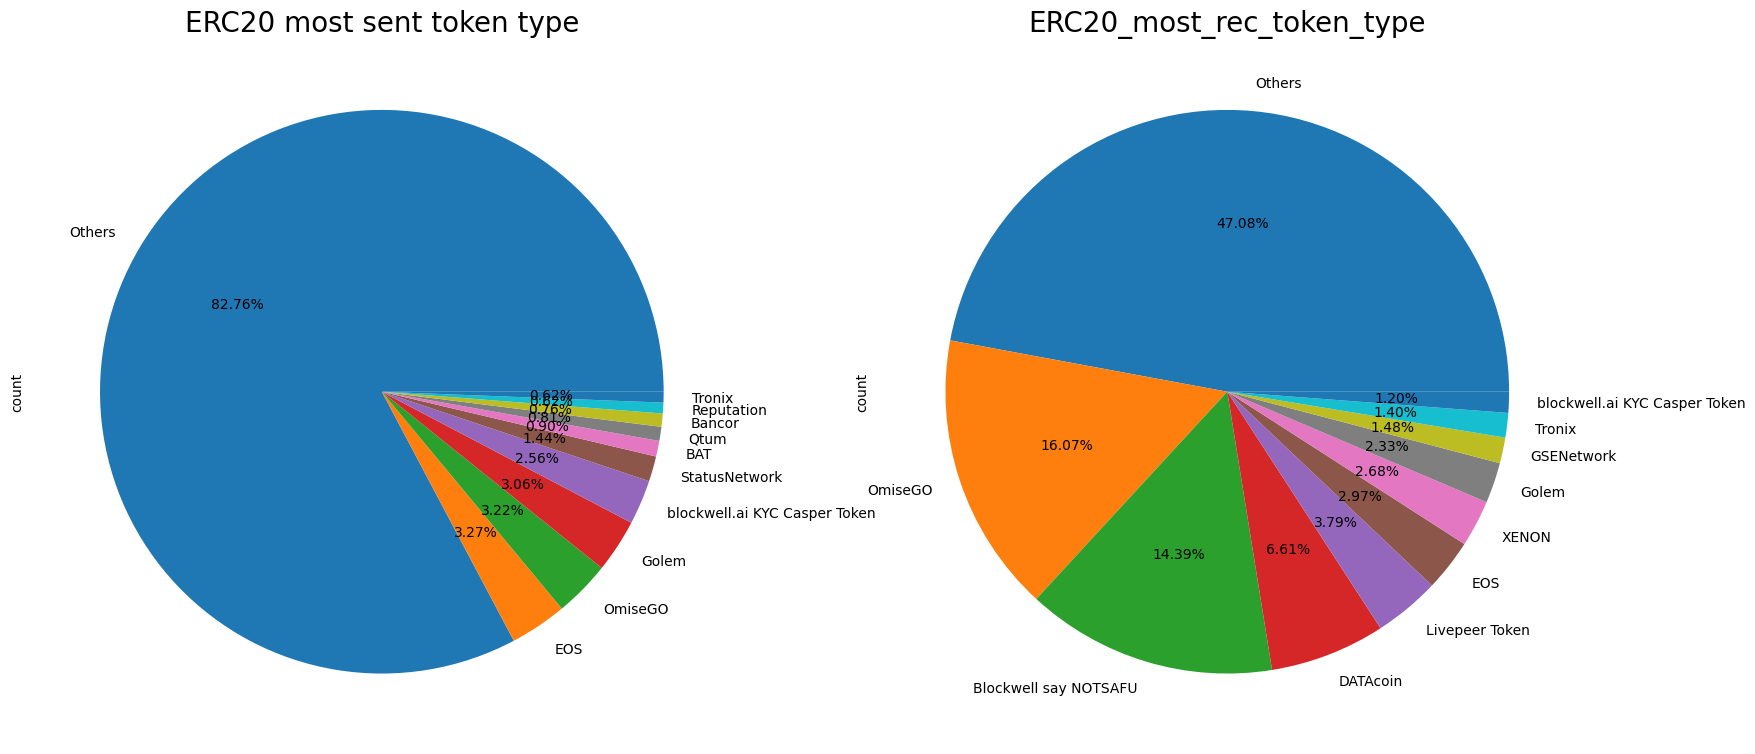

In [46]:
# Frequency Pie Chart after handling
fig, ax = plt.subplots(1,2, figsize=(20,15))

n = 0
for i in cat_cols:
    X[i].value_counts().plot(kind='pie', autopct='%.2f%%', ax=ax[n]).set_title(i,fontsize=20)
    n += 1

The number of categories in each column have been reduced to 11 group (including 'Others') from 300 - 400 groups

## **Train Test Split**

Set `test_size = 0.3` to prevent overfit

In [47]:
# Split Train & Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=21, stratify=y)

# Show rows & columns
print('Train Set:', X_train.shape)
print('Test Set:', X_test.shape)

Train Set: (6876, 48)
Test Set: (2947, 48)


In [48]:
# Check missing values in y
print(y_train.isnull().sum())
print(y_test.isnull().sum())

0
0


There's no missing value in both `y_train` & `y_test`.

Text(0.5, 1.0, 'y_test')

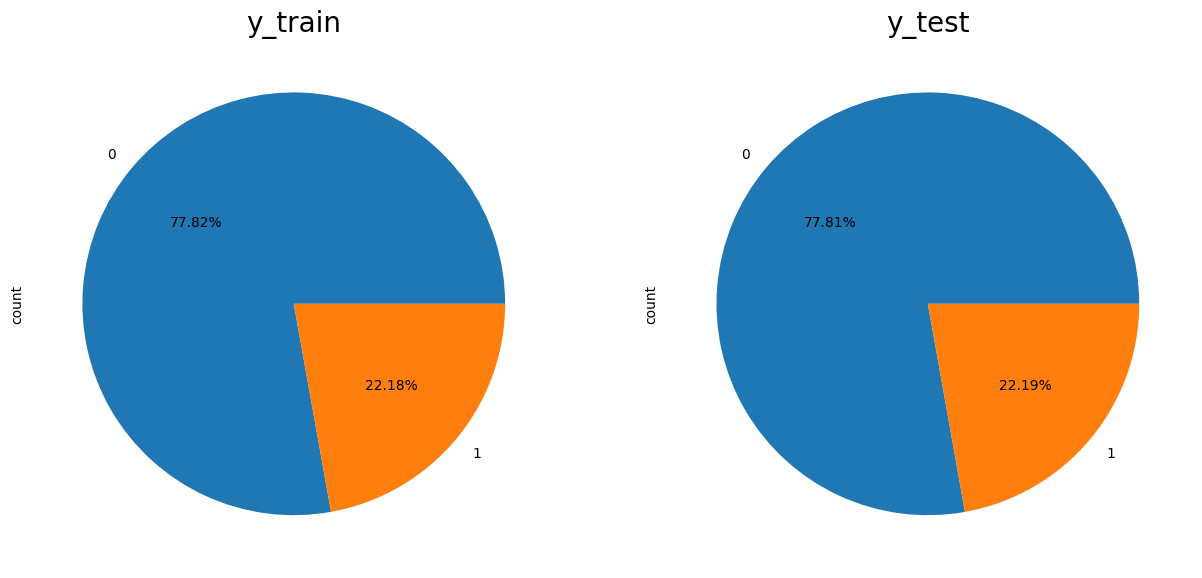

In [49]:
# Check class proportion in y
fig, ax = plt.subplots(1,2, figsize=(15,15))
y_train.value_counts().plot(kind='pie',autopct='%.2f%%',ax=ax[0]).set_title('y_train',fontsize=20)
y_test.value_counts().plot(kind='pie',autopct='%.2f%%',ax=ax[1]).set_title('y_test', fontsize=20)

Both y_train & y_test have the same proportion since we've set `stratify = y` parameters earlier. According to [Faheem U.R.S. (2024)](https://medium.com/@faheemsiddiqi789/how-can-i-determine-if-my-data-is-balanced-or-imbalanced-080819af408c), the common rule of thumb is if the minority class represents < 10-20% of the total samples, the data is considered as imbalanced data. Since class `1` contributes 22% of the total samples, this dataset doesn't necessarily go through the `SMOTE` or `Random Undersampling` process, unless needed.

- `0` = Verified Transaction
- `1` = Fraud Transaction

## **Handling Missing Values**

### **Numerical Missing Values**

In [50]:
# Check total missing values in X_train
X_train.isnull().sum()

Address                                                    0
Avg min between sent tnx                                   0
Avg min between received tnx                               0
Time Diff between first and last (Mins)                    0
Sent tnx                                                   0
Received Tnx                                               0
Number of Created Contracts                                0
Unique Received From Addresses                             0
Unique Sent To Addresses                                   0
min value received                                         0
max value received                                         0
avg val received                                           0
min val sent                                               0
max val sent                                               0
avg val sent                                               0
min value sent to contract                                 0
max val sent to contract

In [51]:
# Check total missing values in X_test
X_test.isnull().sum()

Address                                                    0
Avg min between sent tnx                                   0
Avg min between received tnx                               0
Time Diff between first and last (Mins)                    0
Sent tnx                                                   0
Received Tnx                                               0
Number of Created Contracts                                0
Unique Received From Addresses                             0
Unique Sent To Addresses                                   0
min value received                                         0
max value received                                         0
avg val received                                           0
min val sent                                               0
max val sent                                               0
avg val sent                                               0
min value sent to contract                                 0
max val sent to contract

In [52]:
# Count % numerical null values
print('Train Set:',round(662*100 / X_train.shape[0],2))
print('Test Set:',round(167*100 / X_test.shape[0],2))

Train Set: 9.63
Test Set: 5.67


Null values > 5% --> use capping method instead of drop all null values.

In [53]:
# Displaying all columns instead of '...'
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [54]:
# Filtering ERC20 transaction columns with missing values
X_train[X_train['Total ERC20 tnxs'].isnull()]

,Address,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,avg val received,min val sent,max val sent,avg val sent,min value sent to contract,max val sent to contract,avg value sent to contract,total transactions (including tnx to create contract,total Ether sent,total ether received,total ether sent contracts,total ether balance,Total ERC20 tnxs,ERC20 total Ether received,ERC20 total ether sent,ERC20 total Ether sent contract,ERC20 uniq sent addr,ERC20 uniq rec addr,ERC20 uniq sent addr.1,ERC20 uniq rec contract addr,ERC20 avg time between sent tnx,ERC20 avg time between rec tnx,ERC20 avg time between rec 2 tnx,ERC20 avg time between contract tnx,ERC20 min val rec,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
8653,0x751d37b94dca1ba7a5f5b46e4fb33ecf27f3bdfc,3420.34,86.52,13854.40,4,2,0,2,4,0.313185,0.600000,0.456593,0.094040,0.595701,0.227435,0.0,0.0,0.0,6,0.909741,0.913185,0.0,0.003444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Others,Others
9534,0xdefb014b9e2f3bd81cdb084821f99b681cfca695,1377.26,2822.32,8399.17,2,2,0,2,2,1.000000,5.000000,3.000000,0.100000,5.898000,2.999000,0.0,0.0,0.0,4,5.998000,6.000000,0.0,0.002000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Others,Others
9323,0xc4625787be3fccff6ac2971945806acc167c8cbd,703.77,100.96,2316.22,2,9,0,9,2,0.050000,3.638500,0.808861,3.630000,3.640000,3.635000,0.0,0.0,0.0,11,7.270000,7.279751,0.0,0.009751,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Others,Others
9269,0xbc85a12364c9e375801c00aad17b893fc4c8f5b6,2832.43,12801.78,137875.47,8,9,0,3,7,0.200200,0.601958,0.312760,0.099319,0.601518,0.351414,0.0,0.0,0.0,17,2.811316,2.814844,0.0,0.003528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Others,Others
9038,0xa2b9e771b124abc417884b3a112992bb70d7bdf1,0.00,0.00,0.00,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0,0.000000,0.000000,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Others,Others
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9612,0xe74b02131ed2184eb94fd357b4f303e6935367f5,0.00,309.38,959.73,1,3,0,3,1,0.200000,5.091000,2.000270,5.999950,5.999950,5.999950,0.0,0.0,0.0,4,5.999950,6.000811,0.0,0.000861,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Others,Others
9491,0xd9a1968aec13220e91a31d602f2519262b38dd3a,1176.95,66.95,4975.58,4,4,0,3,4,0.057800,1.000000,0.539450,0.060000,1.935868,0.538967,0.0,0.0,0.0,8,2.155868,2.157800,0.0,0.001932,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Others,Others
8735,0x7f2b4801c338a7b3cc322bfaf151afea8708e8e0,0.00,0.00,7972.27,1,1,0,1,1,2.500000,2.500000,2.500000,2.499580,2.499580,2.499580,0.0,0.0,0.0,2,2.499580,2.500000,0.0,0.000420,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Others,Others
9402,0xce52d38539e1e557f184f1073a59f69c9ba95f28,328.80,838.22,4668.05,4,4,0,4,4,0.500000,38.000000,17.150000,11.596640,19.000000,17.149160,0.0,0.0,0.0,8,68.596640,68.600000,0.0,0.003360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Others,Others


As mentioned earlier, all ERC-20 transaction features are correlated one to another. However, these features don't have any dependencies from other columns. All the numerical cols are missing, but the categorical cols (`ERC20 most sent token type`	& `ERC20_most_rec_token_type`) don't. This indicates there's at least 1 transaction activity in both sending & receiving ERC-20 tokens from these wallet addresses.

Hence, the missing value type is considered as `MAR` and will be imputed using the median value.

In [55]:
# Define imputer
median_imputer = SimpleImputer(strategy='median')

# Assign missing values numerical cols into a variable
num_missing = num_cols[22:]

# Apply imputer to Train & Test set
for i in num_missing:
    X_train[[i]] = median_imputer.fit_transform(X_train[[i]])
    X_test[[i]] = median_imputer.transform(X_test[[i]]) 

In [56]:
# Final check after imputing process
print(X_train[num_cols].isnull().sum().sum())
print(X_test[num_cols].isnull().sum().sum())

0
0


There's no missing values left in the numerical columns.

### **Categorical Missing Values**

In [57]:
# Total categorical null values in Train & Test set
print('Train Set\n', X_train[cat_cols].isnull().sum(),'\n')
print('Test Set\n', X_test[cat_cols].isnull().sum())

Train Set
 ERC20 most sent token type    3925
ERC20_most_rec_token_type     3093
dtype: int64 

Test Set
 ERC20 most sent token type    1676
ERC20_most_rec_token_type     1316
dtype: int64


In [58]:
# Calculate % null in Train set
for i in cat_cols:
    tot_miss = X_train[i].isnull().sum()
    print(f'{i}: {round(tot_miss*100 / X_train.shape[0],2)}%')

ERC20 most sent token type: 57.08%
ERC20_most_rec_token_type: 44.98%


In [59]:
# Calculate % null in Test set
for i in cat_cols:
    tot_miss = X_test[i].isnull().sum()
    print(f'{i}: {round(tot_miss*100 / X_test.shape[0],2)}%')

ERC20 most sent token type: 56.87%
ERC20_most_rec_token_type: 44.66%


Due to the high percentage of missing values, the missing values can not be ignored & dropped.

In [60]:
# Show the missing values rows
X_train[X_train[cat_cols].isnull().any(axis=1)]

,Address,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,avg val received,min val sent,max val sent,avg val sent,min value sent to contract,max val sent to contract,avg value sent to contract,total transactions (including tnx to create contract,total Ether sent,total ether received,total ether sent contracts,total ether balance,Total ERC20 tnxs,ERC20 total Ether received,ERC20 total ether sent,ERC20 total Ether sent contract,ERC20 uniq sent addr,ERC20 uniq rec addr,ERC20 uniq sent addr.1,ERC20 uniq rec contract addr,ERC20 avg time between sent tnx,ERC20 avg time between rec tnx,ERC20 avg time between rec 2 tnx,ERC20 avg time between contract tnx,ERC20 min val rec,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
4400,0x7582d5e2a3f7f45466dd9b6c65d7fb30f7ab5f09,3.62,0.00,10.87,3,2,0,2,3,456.149682,1544.850318,1000.500000,2.703074,1953.375341,666.999528,0.0,0.0,0.0,5,2000.998585,2001.000000,0.0,0.001415,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None
2731,0x47876ad41dd8feefa2eb2e0903d5b944029a2dd7,0.00,22653.16,815513.72,0,36,1,1,0,1.010464,1.127241,1.019044,0.000000,0.000000,0.000000,0.0,0.0,0.0,37,0.000000,36.685600,0.0,36.685600,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None
5962,0xa00b8ecfc688b7b7cb29512e17305809b0fdfc18,2.07,0.00,6.20,3,2,0,2,3,525.303927,1475.696073,1000.500000,0.001000,1452.029105,666.999528,0.0,0.0,0.0,5,2000.998585,2001.000000,0.0,0.001415,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None
2289,0x3bc4635c70f259938d8216f17443a72df0747a28,3.94,0.00,11.82,3,2,0,2,3,639.830076,1361.169924,1000.500000,1.000000,1168.926353,666.999528,0.0,0.0,0.0,5,2000.998585,2001.000000,0.0,0.001415,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None
3533,0x5e79e5b31bf9bc21a34c8a30f152ee20684d4fa0,21.44,8172.09,524235.90,57,64,0,7,2,0.115128,77.030000,23.097167,0.849293,77.029392,25.932982,0.0,0.0,0.0,121,1478.179996,1478.218656,0.0,0.038660,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7858,0x17980b9ff9b318c93263ed52d19f3ca7ad24ed9a,0.00,74.46,79027.65,1,5,0,4,1,0.038829,0.552820,0.243988,1.219079,1.219079,1.219079,0.0,0.0,0.0,6,1.219079,1.219940,0.0,0.000861,1.0,13.37,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,13.37,13.37,13.37,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,None,Blockwell say NOTSAFU
3377,0x59806228fd47e97d26c8d71ab6f0acda022e6a51,3.17,2484.04,79590.72,32,32,0,14,1,0.100000,7.000000,1.093747,0.099580,6.999580,1.093327,0.0,0.0,0.0,64,34.986471,34.999911,0.0,0.013440,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None
2923,0x4c97ccdaa61ca167e8a3b4d425ae6fbf16bcb39c,108.00,1.24,326.48,3,2,0,2,3,28.415669,72.584331,50.500000,0.001084,100.947427,33.666171,0.0,0.0,0.0,5,100.998512,101.000000,0.0,0.001488,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None
3385,0x59bace5e30f68701e84ed92c5f6afbc90183ae40,86.65,4899.29,837638.82,168,168,0,3,3,0.014059,2.198131,0.842743,0.013639,2.197711,0.842322,0.0,0.0,0.0,336,141.510177,141.580759,0.0,0.070581,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

Majority of the missing ERC-20 token name happened due to no ERC-20 transaction from those users (ERC-20 trx cols data = 0). Thus, these missing values can be categorized as `MAR`.

Due to the fact that the missing values contribute more than 40-50% of total data in both Train & Test set, imputing using `.mode()` will make the data highly imbalance & might effect the model and making it biased. Thus, all missing values will be imputed to a new category, which is `Unknown`.

In [61]:
# Define imputer
missing_imputer = SimpleImputer(strategy='constant',fill_value='Unknown',missing_values=None)

# Apply imputer to Train & Test set
for i in cat_cols:
    X_train[[i]] = missing_imputer.fit_transform(X_train[[i]])
    X_test[[i]] = missing_imputer.transform(X_test[[i]]) 

In [62]:
# Final check
print('Train:',X_train.isnull().sum().sum())
print('Test:',X_test.isnull().sum().sum())

Train: 0
Test: 0


There's no missing value left in the whole dataset

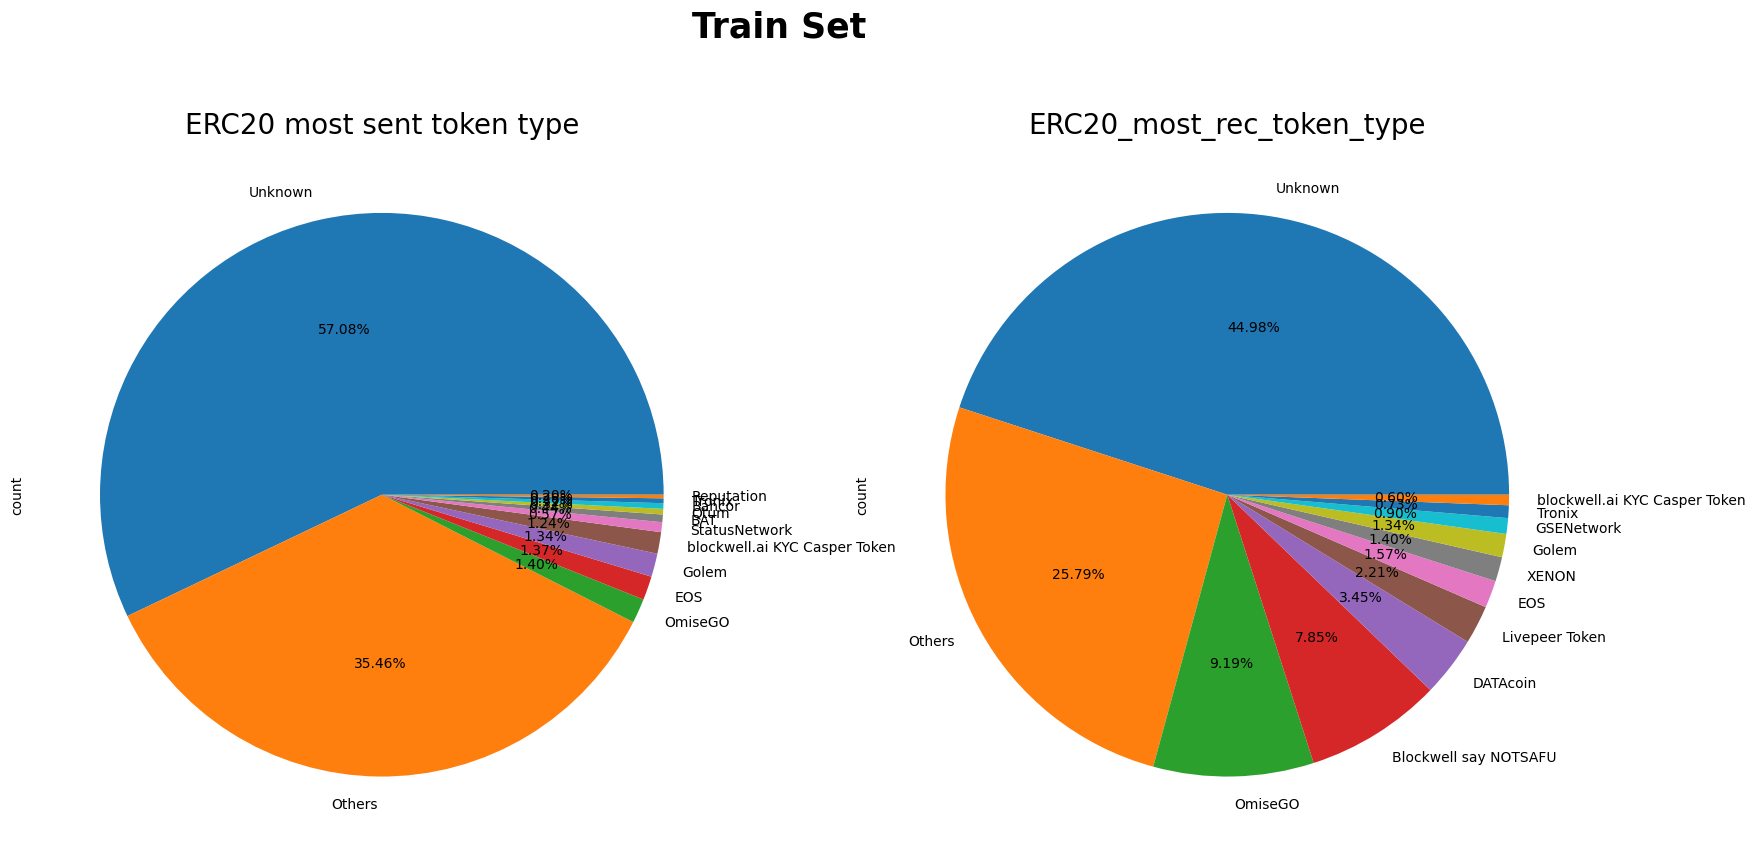

In [63]:
# Frequency Pie Chart after handling --> Train Set
fig, ax = plt.subplots(1,2, figsize=(20,10))
plt.suptitle('Train Set', fontsize=25, fontweight='bold')
n = 0
for i in cat_cols:
    X_train[i].value_counts().plot(kind='pie', autopct='%.2f%%', ax=ax[n]).set_title(i,fontsize=20)
    n += 1

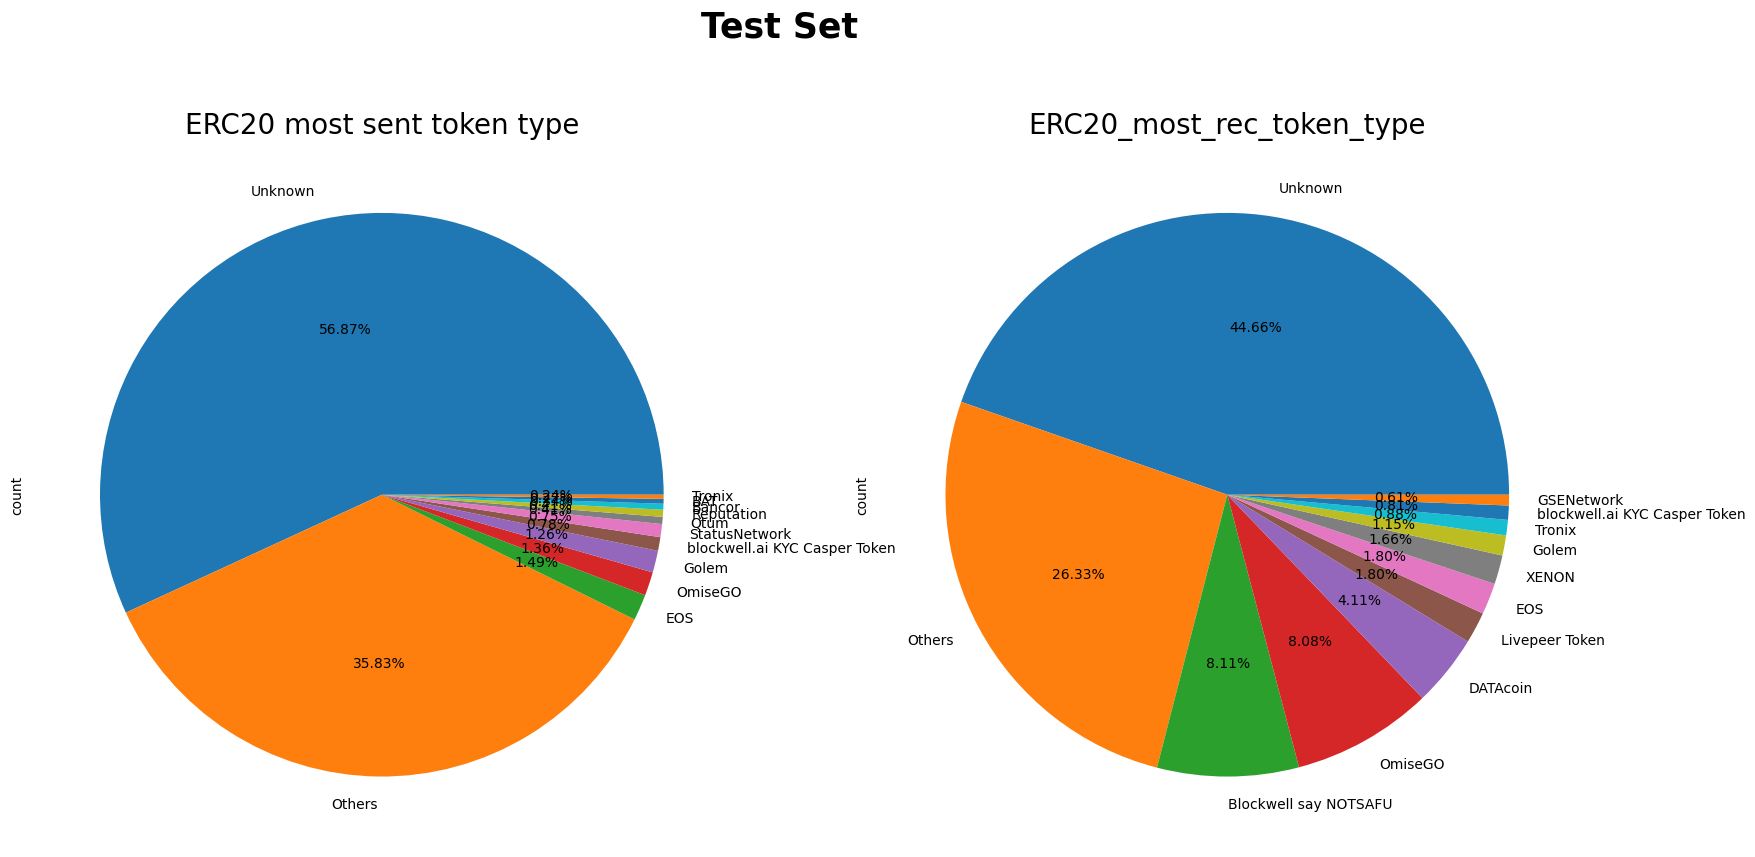

In [64]:
# Frequency Pie Chart after handling --> Test Set
fig, ax = plt.subplots(1,2, figsize=(20,10))
plt.suptitle('Test Set', fontsize=25, fontweight='bold')
n = 0
for i in cat_cols:
    X_test[i].value_counts().plot(kind='pie', autopct='%.2f%%', ax=ax[n]).set_title(i,fontsize=20)
    n += 1

## **Handling Outlier**

In [65]:
# Define a function for skewness
def check_skew(df, column_names):
    return {col: df[col].skew() for col in column_names}

# Loop the function
for k,v in check_skew(X_train, num_cols).items():
  print(f'{k}: {v}')

Avg min between sent tnx: 8.498787043287765
Avg min between received tnx: 5.786973090231895
Time Diff between first and last (Mins): 1.8004362669744407
Sent tnx: 10.550094348213786
Received Tnx: 9.05114088918141
Number of Created Contracts: 54.79244202364833
Unique Received From Addresses: 19.431244658145385
Unique Sent To Addresses: 17.07275791887763
min value received: 24.002938796164685
max value received: 57.54014117307782
avg val received: 81.25167622669164
min val sent: 68.59480663735157
max val sent: 65.88194537303751
avg val sent: 28.413325766448615
min value sent to contract: 0.0
max val sent to contract: 82.92164976651154
avg value sent to contract: 82.92164976651152
total transactions (including tnx to create contract: 6.9277273455686945
total Ether sent: 45.75968090976708
total ether received: 34.203938478707975
total ether sent contracts: 82.9216497665115
total ether balance: -53.75917446555587
Total ERC20 tnxs: 22.0626864951447
ERC20 total Ether received: 82.8398513770085

In [66]:
# Initialize empty lists for each skewness category
normal_columns = []
skewed_columns = []
extreme_skewed_columns = []

# Loop through the skewness values and categorize the columns
for col, skewness in check_skew(X_train,num_cols).items():
    if abs(skewness) > 1.0:
        extreme_skewed_columns.append(col)
    elif abs(skewness) <= 0.5: 
        normal_columns.append(col)
    else:
        skewed_columns.append(col)

# Print the columns in each category
print(f"Normal: {normal_columns}\nSkewed: {skewed_columns}\nExtreme Skewed: {extreme_skewed_columns}")

Normal: ['min value sent to contract', 'ERC20 avg time between sent tnx', 'ERC20 avg time between rec tnx', 'ERC20 avg time between rec 2 tnx', 'ERC20 avg time between contract tnx', 'ERC20 min val sent contract', 'ERC20 max val sent contract', 'ERC20 avg val sent contract']
Skewed: []
Extreme Skewed: ['Avg min between sent tnx', 'Avg min between received tnx', 'Time Diff between first and last (Mins)', 'Sent tnx', 'Received Tnx', 'Number of Created Contracts', 'Unique Received From Addresses', 'Unique Sent To Addresses', 'min value received', 'max value received', 'avg val received', 'min val sent', 'max val sent', 'avg val sent', 'max val sent to contract', 'avg value sent to contract', 'total transactions (including tnx to create contract', 'total Ether sent', 'total ether received', 'total ether sent contracts', 'total ether balance', 'Total ERC20 tnxs', 'ERC20 total Ether received', 'ERC20 total ether sent', 'ERC20 total Ether sent contract', 'ERC20 uniq sent addr', 'ERC20 uniq re

In [67]:
# Check normal cols unique values
for i in normal_columns:
    print(i, X_train[i].unique())

min value sent to contract [0.]
ERC20 avg time between sent tnx [0.]
ERC20 avg time between rec tnx [0.]
ERC20 avg time between rec 2 tnx [0.]
ERC20 avg time between contract tnx [0.]
ERC20 min val sent contract [0.]
ERC20 max val sent contract [0.]
ERC20 avg val sent contract [0.]


Surprisingly, all features in `normal_columns` only have one value, which is `0`. Thus, these feature won't bring any impact to model & can be ignored.

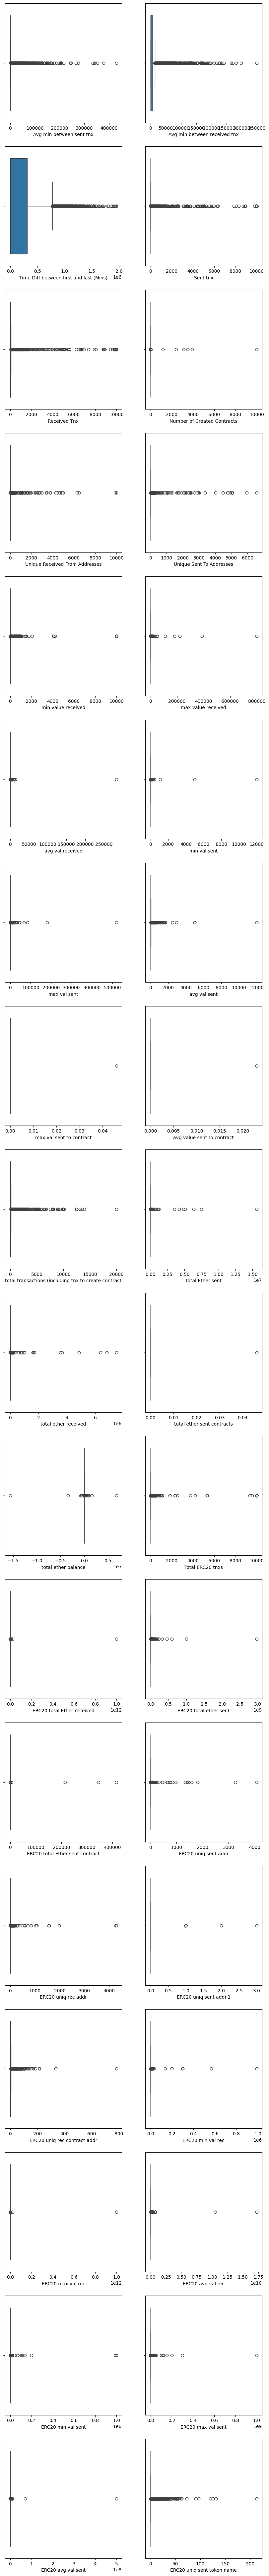

In [68]:
# Boxplot for extremely skewed features
fig = plt.figure(figsize=(10, 100))
row_num = 18
col_num = 2

for i in range(1, row_num*col_num + 1):
  fig.add_subplot(row_num, col_num, i)
  sns.boxplot(data=X_train, x=extreme_skewed_columns[i-1])
plt.show()

Majority of the features are dominantly filled with `0` value.

In [69]:
# define an outlier calculator function
def outlier_function(train_df,train_cols,distance):
  for i in train_cols:
    IQR = train_df[i].quantile(0.75) - train_df[i].quantile(0.25)
    lower_boundary = train_df[i].quantile(0.25) - (IQR * distance)
    upper_boundary = train_df[i].quantile(0.75) + (IQR * distance)

    outliers = train_df[(train_df[i] < lower_boundary) | (train_df[i] > upper_boundary)]
    outlier_percentage = len(outliers)*100 / len(train_df)
    print(f'{i}: {outlier_percentage:.2f}%')

# Calculate outlier
outlier_function(X_train, extreme_skewed_columns, 3) # distance = 3 due to extreme skew

Avg min between sent tnx: 18.27%
Avg min between received tnx: 9.76%
Time Diff between first and last (Mins): 1.24%
Sent tnx: 14.95%
Received Tnx: 13.79%
Number of Created Contracts: 13.55%
Unique Received From Addresses: 7.20%
Unique Sent To Addresses: 12.01%
min value received: 19.63%
max value received: 7.88%
avg val received: 13.26%
min val sent: 11.34%
max val sent: 8.13%
avg val sent: 5.70%
max val sent to contract: 0.01%
avg value sent to contract: 0.01%
total transactions (including tnx to create contract: 11.31%
total Ether sent: 12.17%
total ether received: 13.19%
total ether sent contracts: 0.01%
total ether balance: 29.64%
Total ERC20 tnxs: 14.02%
ERC20 total Ether received: 22.21%
ERC20 total ether sent: 15.87%
ERC20 total Ether sent contract: 0.28%
ERC20 uniq sent addr: 15.87%
ERC20 uniq rec addr: 10.03%
ERC20 uniq sent addr.1: 0.28%
ERC20 uniq rec contract addr: 11.45%
ERC20 min val rec: 23.08%
ERC20 max val rec: 23.73%
ERC20 avg val rec: 21.35%
ERC20 min val sent: 7.88%

Outliers in `extremely_skewed_columns` vary from 0.01% - 29.63%. Hence, these outliers will be processed using capping method.

In [70]:
# Low Variation cols --> can not be capped --> These columns occur on the error message due to low variance issue
low_var_cols = ['Number of Created Contracts', 
 'max val sent to contract', 
 'avg value sent to contract', 
 'total ether sent contracts', 
 'ERC20 total ether sent', 
 'ERC20 total Ether sent contract', 
 'ERC20 uniq sent addr', 
 'ERC20 uniq sent addr.1', 
 'ERC20 min val rec', 
 'ERC20 min val sent', 
 'ERC20 max val sent', 
 'ERC20 avg val sent', 
 'ERC20 uniq sent token name']

# Excluding this low_var_cols from the extremely skewed cols
capping_cols = [i for i in extreme_skewed_columns if i not in low_var_cols]
capping_cols

# Capping using Winsorizer
winsor = Winsorizer(capping_method='iqr', tail='both', fold=3, variables=capping_cols)
X_train = winsor.fit_transform(X_train)

In [71]:
# Check skewness after capping
for k,v in check_skew(X_train, num_cols).items():
  print(f'{k}: {v}')

Avg min between sent tnx: 1.3030861681571757
Avg min between received tnx: 1.625647730563419
Time Diff between first and last (Mins): 1.6216556888790827
Sent tnx: 1.4327551341738312
Received Tnx: 1.473813352945429
Number of Created Contracts: 54.79244202364833
Unique Received From Addresses: 1.670179790237729
Unique Sent To Addresses: 1.2691477173524937
min value received: 1.306608072921297
max value received: 1.9698129396850454
avg val received: 1.470181514349211
min val sent: 1.6637744539422412
max val sent: 1.9096848536295412
avg val sent: 1.8035345647611982
min value sent to contract: 0.0
max val sent to contract: 82.92164976651154
avg value sent to contract: 82.92164976651152
total transactions (including tnx to create contract: 1.506748656899283
total Ether sent: 1.6584201539324017
total ether received: 1.480617397743607
total ether sent contracts: 82.9216497665115
total ether balance: 0.3753239667737111
Total ERC20 tnxs: 1.3340323723736065
ERC20 total Ether received: 1.183880585

Most faetures' skewness have dropped significantly to around 1 - 1.9. The `low_var_cols` skewness values remain high since those column can't be processed.

In [72]:
# Check % outliers after capping
outlier_function(X_train, extreme_skewed_columns,3)

Avg min between sent tnx: 0.00%
Avg min between received tnx: 0.00%
Time Diff between first and last (Mins): 0.00%
Sent tnx: 0.00%
Received Tnx: 0.00%
Number of Created Contracts: 13.55%
Unique Received From Addresses: 0.00%
Unique Sent To Addresses: 0.00%
min value received: 0.00%
max value received: 0.00%
avg val received: 0.00%
min val sent: 0.00%
max val sent: 0.00%
avg val sent: 0.00%
max val sent to contract: 0.01%
avg value sent to contract: 0.01%
total transactions (including tnx to create contract: 0.00%
total Ether sent: 0.00%
total ether received: 0.00%
total ether sent contracts: 0.01%
total ether balance: 0.00%
Total ERC20 tnxs: 0.00%
ERC20 total Ether received: 0.00%
ERC20 total ether sent: 15.87%
ERC20 total Ether sent contract: 0.28%
ERC20 uniq sent addr: 15.87%
ERC20 uniq rec addr: 0.00%
ERC20 uniq sent addr.1: 0.28%
ERC20 uniq rec contract addr: 0.00%
ERC20 min val rec: 23.08%
ERC20 max val rec: 0.00%
ERC20 avg val rec: 0.00%
ERC20 min val sent: 7.88%
ERC20 max val se

Most columns are within the tolerance range after capping the outliers.

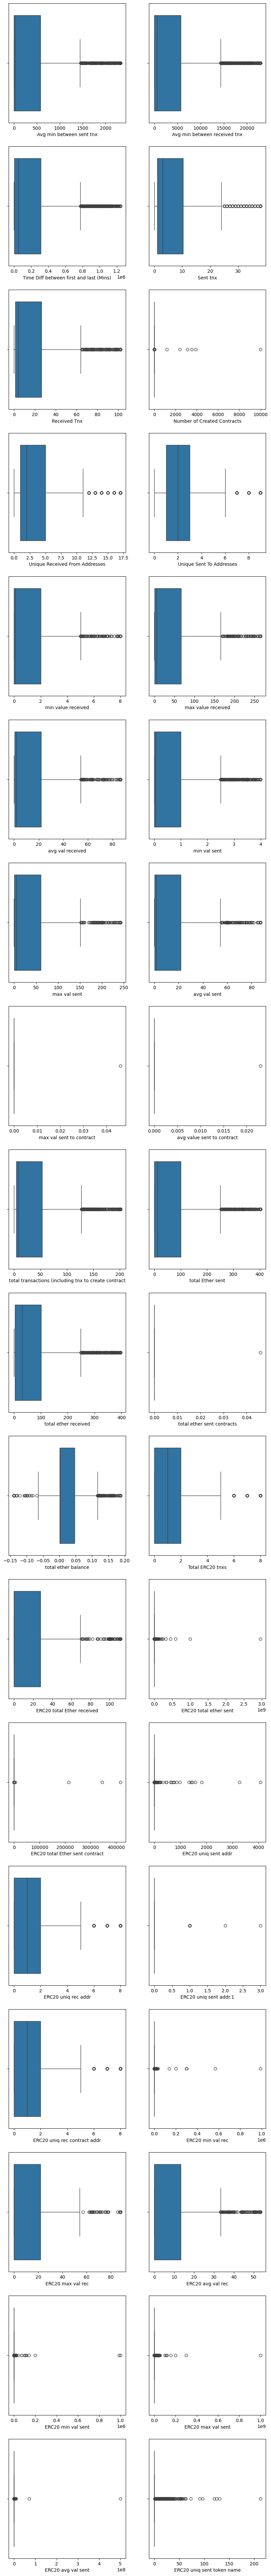

In [73]:
# Boxplot for extremely skewed features
fig = plt.figure(figsize=(10, 100))
row_num = 18
col_num = 2

for i in range(1, row_num*col_num + 1):
  fig.add_subplot(row_num, col_num, i)
  sns.boxplot(data=X_train, x=extreme_skewed_columns[i-1])
plt.show()

The distribution has improved much better based on the Boxplot diagram.

## **Feature Selection**

Drop unnecessary columns:
- Address --> Act as an identifier (similar to ID column in general dataset)
- All columns in `normal_columns` (during outlier handling) --> only contains `0` value

In [74]:
# Drop those columns in X_train & X_test

X_train.drop(columns=(normal_columns+['Address']), inplace=True)
X_test.drop(columns=(normal_columns+['Address']), inplace=True)

### **Correlation Test**

In [75]:
# Merge with target
concat_train = pd.concat([X_train, y_train],axis=1)
concat_train

,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,avg val received,min val sent,max val sent,avg val sent,max val sent to contract,avg value sent to contract,total transactions (including tnx to create contract,total Ether sent,total ether received,total ether sent contracts,total ether balance,Total ERC20 tnxs,ERC20 total Ether received,ERC20 total ether sent,ERC20 total Ether sent contract,ERC20 uniq sent addr,ERC20 uniq rec addr,ERC20 uniq sent addr.1,ERC20 uniq rec contract addr,ERC20 min val rec,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type,FLAG
4400,3.62,0.00,10.87,3,2,0,2,3,7.996766,264.983110,86.327562,2.703074,242.020730,87.393718,0.0,0.0,5,403.161783,395.451464,0.0,0.001415,0.0,0.000000e+00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.00,0.00,0.00,0.00,0.0,0.0,Unknown,Unknown,0
492,2320.48,1442.85,558132.17,38,102,0,17,3,0.010891,62.010000,23.536926,0.000000,242.020730,87.393718,0.0,0.0,182,403.161783,395.451464,0.0,0.021024,8.0,1.111879e+02,13383.63,0.0,1.0,7.0,0.0,1.0,1.0,87.848,53.48,13383.63,13383.63,13383.63,1.0,1.0,EOS,EOS,0
2731,0.00,22653.16,815513.72,0,36,1,1,0,1.010464,1.127241,1.019044,0.000000,0.000000,0.000000,0.0,0.0,37,0.000000,36.685600,0.0,0.186605,0.0,0.000000e+00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.00,0.00,0.00,0.00,0.0,0.0,Unknown,Unknown,0
5962,2.07,0.00,6.20,3,2,0,2,3,7.996766,264.983110,86.327562,0.001000,242.020730,87.393718,0.0,0.0,5,403.161783,395.451464,0.0,0.001415,0.0,0.000000e+00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.00,0.00,0.00,0.00,0.0,0.0,Unknown,Unknown,0
2289,3.94,0.00,11.82,3,2,0,2,3,7.996766,264.983110,86.327562,1.000000,242.020730,87.393718,0.0,0.0,5,403.161783,395.451464,0.0,0.001415,0.0,0.000000e+00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.00,0.00,0.00,0.00,0.0,0.0,Unknown,Unknown,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3377,3.17,2484.04,79590.72,32,32,0,14,1,0.100000,7.000000,1.093747,0.099580,6.999580,1.093327,0.0,0.0,64,34.986471,34.999911,0.0,0.013440,0.0,0.000000e+00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.00,0.00,0.00,0.00,0.0,0.0,Unknown,Unknown,0
8876,0.00,0.00,0.00,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0,0.000000,0.000000,0.0,0.000000,1.0,9.555000e-13,0.00,0.0,0.0,1.0,0.0,1.0,0.0,0.000,0.00,0.00,0.00,0.00,0.0,1.0,Others,Others,1
2923,108.00,1.24,326.48,3,2,0,2,3,7.996766,72.584331,50.500000,0.001084,100.947427,33.666171,0.0,0.0,5,100.998512,101.000000,0.0,0.001488,0.0,0.000000e+00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.00,0.00,0.00,0.00,0.0,0.0,Unknown,Unknown,0
3385,86.65,4899.29,837638.82,38,102,0,3,3,0.014059,2.198131,0.842743,0.013639,2.197711,0.842322,0.0,0.0,201,141.510177,141.580759,0.0,0.070581,0.0,0.000000e+00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.00,0.00,0.00,0.00,0.0,0.0,Unknown,Unknown,0


In [76]:
# define phi-k correlation function
def phik_corr(df, columns, target):
 corr_matrix = df[columns].phik_matrix()
 return corr_matrix[target]

# Apply the function
phik_corr(concat_train,concat_train.columns,'FLAG').sort_values(ascending=False)

interval columns not set, guessing: ['Avg min between sent tnx', 'Avg min between received tnx', 'Time Diff between first and last (Mins)', 'Sent tnx', 'Received Tnx', 'Number of Created Contracts', 'Unique Received From Addresses', 'Unique Sent To Addresses', 'min value received', 'max value received', 'avg val received', 'min val sent', 'max val sent', 'avg val sent', 'max val sent to contract', 'avg value sent to contract', 'total transactions (including tnx to create contract', 'total Ether sent', 'total ether received', 'total ether sent contracts', 'total ether balance', 'Total ERC20 tnxs', 'ERC20 total Ether received', 'ERC20 total ether sent', 'ERC20 total Ether sent contract', 'ERC20 uniq sent addr', 'ERC20 uniq rec addr', 'ERC20 uniq sent addr.1', 'ERC20 uniq rec contract addr', 'ERC20 min val rec', 'ERC20 max val rec', 'ERC20 avg val rec', 'ERC20 min val sent', 'ERC20 max val sent', 'ERC20 avg val sent', 'ERC20 uniq sent token name', 'ERC20 uniq rec token name', 'FLAG']


FLAG                                                    1.000000
ERC20_most_rec_token_type                               0.899548
Total ERC20 tnxs                                        0.727715
ERC20 uniq rec addr                                     0.695794
ERC20 uniq rec contract addr                            0.691882
ERC20 uniq rec token name                               0.691829
total ether received                                    0.515486
total Ether sent                                        0.456477
ERC20 total Ether received                              0.437490
ERC20 max val rec                                       0.426690
avg val received                                        0.423141
max value received                                      0.420136
ERC20 avg val rec                                       0.418156
Time Diff between first and last (Mins)                 0.387915
min value received                                      0.382182
max val sent             

**Correlation Threshold** ([Schober *et al.,* 2018](https://www.researchgate.net/publication/323388613_Correlation_Coefficients_Appropriate_Use_and_Interpretation)):
|Correlation Coefficient|Interpreation|
|---|---|
|0.00 - 0.10| Negligible Correlation|
|0.10 - 0.39| Weak Correlation|
|0.40 - 0.69| Moderate Correlation|
|0.70 - 0.89| Strong Correlation|
|0.90 - 1.00| Very Strong Correlation|

According to the threshold, all columns with correlation value < 0.1 can be neglected.

In [77]:
# Assign to weak cols variable
weak_cols = ['ERC20 min val sent',
'ERC20 max val sent',
'ERC20 avg val sent',
'ERC20 uniq sent token name',
'ERC20 min val rec',
'ERC20 uniq sent addr.1',
'ERC20 uniq sent addr',
'ERC20 total ether sent',
'ERC20 total Ether sent contract',
'total ether sent contracts',
'max val sent to contract',
'avg value sent to contract',
'Number of Created Contracts',
'Avg min between sent tnx']

# Drop weak cols
X_train.drop(columns=weak_cols, inplace=True)
X_test.drop(columns=weak_cols, inplace=True)

In [78]:
# Update num_cols after removing normal_columns
new_num_cols = [i for i in num_cols if i not in (normal_columns + weak_cols)]

### **Feature Scaling & Encoding**

- Feature Scaling --> using `MinMaxScaler()` due to skewed distribution of all numerical columns

- Feature Encoding --> using `OneHotEncoder()` beacuse all the categorical columns only represent the token's name --> should be a nominal encoded category

In [79]:
# Scaling & Encoding Pipe
scaler_pipe = make_pipeline(MinMaxScaler())
ohe_pipe = make_pipeline (OneHotEncoder(handle_unknown='ignore', sparse_output=False))

# Combine both num & cat
preprocess_pipe = ColumnTransformer([
    ('num', scaler_pipe, new_num_cols),
    ('cat', ohe_pipe, cat_cols )
])

### **PCA Processing**

Before PCA, all features must be scaled & encoded. Because the Scaling & Encoding will be conducted through the pipeline, the original `X_train` can not be transform to prevent double scaling & encoding. Hence, we will create a copy of X_train df.

In [80]:
# Copy
X_train_copy = X_train.copy()

# Scaling & Encoding
X_train_copy = preprocess_pipe.fit_transform(X_train_copy)
X_train_copy.shape

(6876, 47)

After scaling & encoding, total columns increase to 47 columns

In [81]:
# Determine total features to retain ≥ 95 % of the information
pca = PCA()
pca.fit(X_train_copy)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

Text(0, 0.5, 'Eigenvalues')

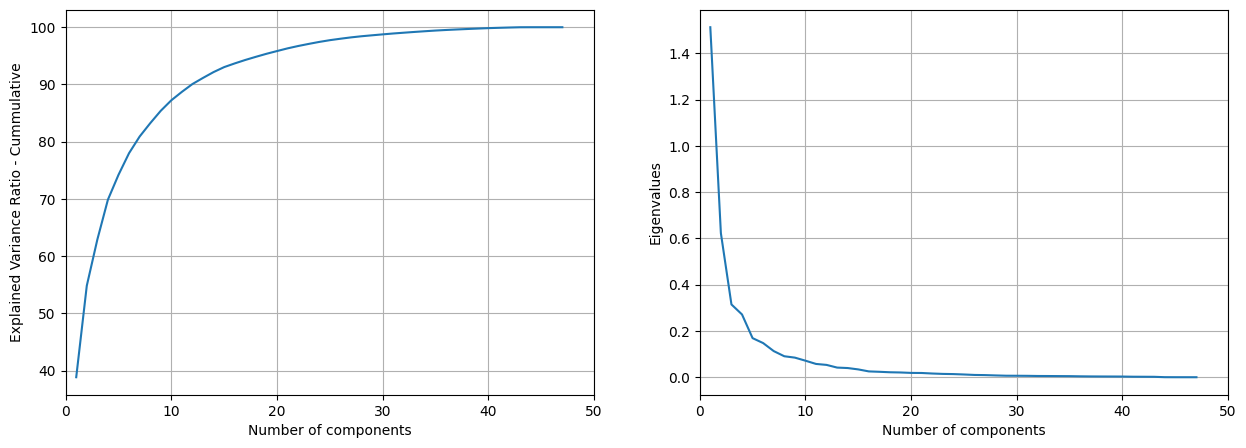

In [82]:
# Plot the Cummulative of Explained Variance Ratio
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.grid()
plt.plot(range(1, 48), np.cumsum(pca.explained_variance_ratio_ * 100))
plt.xlim(0,50)
plt.xlabel('Number of components')
plt.ylabel('Explained Variance Ratio - Cummulative')

# Plot the Eigenvalues
plt.subplot(1, 2, 2)
plt.grid()
plt.plot(range(1, 48), pca.explained_variance_ )
plt.xlim(0,50)
plt.xlabel('Number of components')
plt.ylabel('Eigenvalues')

To retain at least 95% of all informations, we only need to use roughly 20 features.

In [83]:
# Determine total features to retain ≥ 95 % of the information
cumsum = np.cumsum(pca.explained_variance_ratio_)
tot_features = np.argmax(cumsum >= 0.95) + 1
tot_features

np.int64(19)

Only 19 columns will be used according to the calculation. This has been reduced significantly from 47 columns before PCA.

The PCA process will be added to the pipeline for the original `X_train` with `n_components = 19`.

## **Imbalanced Data Handling**

To prevent an overfit model, the imbalanced class will be reduce manually using `Random Undersampling` method instead of SMOTE (oversampling) because that technique basically manipulating "dummy" data although using mathematical distance approach.

In [84]:
# Target class frequency
y_train.value_counts()

FLAG
0    5351
1    1525
Name: count, dtype: int64

To achieve a `50:50` ratio between classes, we need to remove `3826 data` in the dominant class.

In [85]:
# Random sampling 3826 data
imb_index = y_train[y_train==0].sample(n=3826, random_state=21).index # random_state for consistent reproducibility

# remove the data in X_train & y_train
y_train.drop(index=imb_index, inplace=True)
X_train.drop(index=imb_index, inplace=True)

In [86]:
# Check frequency
y_train.value_counts()

FLAG
0    1525
1    1525
Name: count, dtype: int64

In [87]:
# Count total rows in X & y train
print(X_train.shape)
print(y_train.shape)

(3050, 25)
(3050,)


The train data is now balanced.

In [88]:
y_test.value_counts()

FLAG
0    2293
1     654
Name: count, dtype: int64

# **VI. MODEL DEFINITION**

***Models:***

- KNN : Used as the base model due to its simplicity, minimum hyperparameter, fast computing time, & non-parametric (no assumptions needed)

- SVC : Effective in handling non-linear distribution & adjustable kernel methods (linear / polynomial / RBF)

- Decision Tree: Using `IF-Else` framework, simple model, effective in handling high-dimensional data, & no assumption needed

- Random Forest: An ensemble learning model of Decision Tree, less bias, better accuracy, & no assumption needed

- Boosting : XGBoost --> Less sensitve to outliers compared to Adaboost & performs well in handling imbalanced data, like financial fraud cases

***Parameters:***

In financial fraud case, higher false negative cases (predicted = Safe Transcation, but it's actually a fraud) are more dangerous than false positive.

Metrics:
- FN
- Recall --> Reduce FN as low as possible
- AUC Score --> Measure how well a model distinguish between classes

In [74]:
# Pipeline
pipe_knn = make_pipeline(preprocess_pipe, PCA(n_components=19),KNeighborsClassifier())
pipe_svc = make_pipeline(preprocess_pipe, PCA(n_components=19),SVC(random_state=21))
pipe_dt = make_pipeline(preprocess_pipe, PCA(n_components=19),DecisionTreeClassifier(random_state=21))
pipe_rf = make_pipeline(preprocess_pipe, PCA(n_components=19),RandomForestClassifier(random_state=21))
pipe_xgb = make_pipeline(preprocess_pipe, PCA(n_components=19),XGBClassifier(random_state=21))

Excluding imputer in pipeline due to some column have been deleted in outlier handling

In [75]:
# SKFold
skfold = StratifiedKFold(n_splits=5)

# Cross Validation for each model
cv_knn = cross_val_score(pipe_knn, X_train, y_train, cv=skfold, scoring='recall', n_jobs=-1)
cv_svc = cross_val_score(pipe_svc, X_train, y_train, cv=skfold, scoring='recall', n_jobs=-1)
cv_dt = cross_val_score(pipe_dt, X_train, y_train, cv=skfold, scoring='recall', n_jobs=-1)
cv_rf = cross_val_score(pipe_rf, X_train, y_train, cv=skfold, scoring='recall', n_jobs=-1)
cv_xgb = cross_val_score(pipe_xgb, X_train, y_train, cv=skfold, scoring='recall', n_jobs=-1)

In [76]:
# Finding the Best Model based on cv-score (mean)
name_model = []
cv_scores = 0
for cv,name in zip([cv_knn, cv_svc, cv_dt, cv_rf, cv_xgb],
                   ['knn_model','svc_model', 'dt_model', 'rf_model', 'xgb_model']):
  print(name)
  print('Recall - All - Cross Validation :', cv)
  print('Recall - Mean - Cross Validation :', cv.mean())
  print('Recall - std - Cross Validation :', cv.std())
  print('Recall - Range of Test Set :', (cv.mean()-cv.std()), '-' , (cv.mean()+cv.std()))
  print('-'*50)
  if cv.mean() > cv_scores:
    cv_scores = cv.mean()
    name_model = name
  else:
    pass
print('Best Model:', name_model)
print('Cross Val Mean from Best Model:', cv_scores)

knn_model
Recall - All - Cross Validation : [0.94754098 0.93770492 0.98032787 0.9704918  0.96721311]
Recall - Mean - Cross Validation : 0.960655737704918
Recall - std - Cross Validation : 0.015655523129591252
Recall - Range of Test Set : 0.9450002145753267 - 0.9763112608345093
--------------------------------------------------
svc_model
Recall - All - Cross Validation : [0.96393443 0.93770492 0.98032787 0.96721311 0.96065574]
Recall - Mean - Cross Validation : 0.9619672131147541
Recall - std - Cross Validation : 0.013848335791437955
Recall - Range of Test Set : 0.9481188773233161 - 0.975815548906192
--------------------------------------------------
dt_model
Recall - All - Cross Validation : [0.94098361 0.93114754 0.97704918 0.95409836 0.95737705]
Recall - Mean - Cross Validation : 0.9521311475409835
Recall - std - Cross Validation : 0.01560049475851845
Recall - Range of Test Set : 0.9365306527824651 - 0.9677316422995019
--------------------------------------------------
rf_model
Recal

Based on the averge cross validation scores, XGBoost model shows the highest score. This model will be used for further train & test steps.

# **VII. MODEL TRAINING**

In [77]:
# Fit model to the train set
pipe_xgb.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [78]:
# Predict model
y_pred_train = pipe_xgb.predict(X_train)
y_pred_test = pipe_xgb.predict(X_test)

# **VIII. MODEL EVALUATION**

## **Before Tuning**

In [79]:
# Recall score
print('Recall Train:', recall_score(y_train, y_pred_train))
print('Recall Test:', recall_score(y_test, y_pred_test))

Recall Train: 1.0
Recall Test: 0.9113149847094801


This indicates that the model is overfit, due to perfect recall score in train set and the gap between train & test score is more than 5% (8.87%).

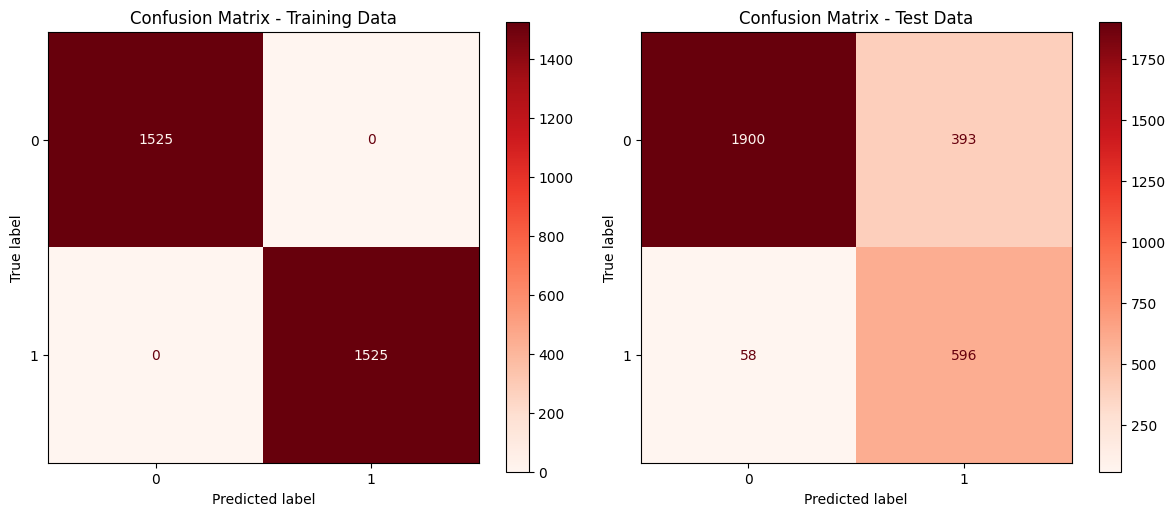

In [80]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot confusion matrix for training data
train_matrix = ConfusionMatrixDisplay.from_estimator(pipe_xgb, X_train, y_train, cmap='Reds',ax=axes[0])
train_matrix.ax_.set_title('Confusion Matrix - Training Data')

# Plot confusion matrix for test data
test_matrix = ConfusionMatrixDisplay.from_estimator(pipe_xgb, X_test, y_test, cmap='Reds',ax=axes[1])
test_matrix.ax_.set_title('Confusion Matrix - Test Data')

plt.tight_layout()
plt.show()

In the test set, there are 58 false negative data & 1900 true negative data. To find out the characteristics, we need to merge `y_test` & `y_pred_test` into one df.

In [81]:
# Concat into 1 df
test_temp = pd.concat([X_test,y_test], axis=1)
test_temp['pred_test'] = y_pred_test
test_temp

,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,avg val received,min val sent,max val sent,avg val sent,total transactions (including tnx to create contract,total Ether sent,total ether received,total ether balance,Total ERC20 tnxs,ERC20 total Ether received,ERC20 uniq rec addr,ERC20 uniq rec contract addr,ERC20 max val rec,ERC20 avg val rec,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type,FLAG,pred_test
3050,8205.72,241553.23,9,12,1,1,0.361438,36.889000,7.775261,0.005059,36.886000,10.366533,21,93.298800,93.303131,0.004331,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,Unknown,Unknown,0,0
9476,2841.02,275214.32,55,45,21,14,0.000100,15.000000,2.295850,0.000000,23.800000,1.877316,100,103.252358,103.313259,0.060902,26.0,4.369653e+07,12.0,13.0,2.200000e+07,2.913102e+06,12.0,Others,Others,1,1
3464,1461.06,176626.48,41,3,3,15,0.795000,2.248768,1.631250,0.000000,1.200000,0.140976,44,5.780000,4.893751,-0.886249,35.0,2.775044e+04,18.0,18.0,1.000000e+04,1.156268e+03,18.0,EOS,Others,0,1
4589,12424.90,958759.38,81,65,11,1,0.004985,70.203000,9.455185,0.004895,70.202640,11.138925,146,902.252934,614.587051,-287.665883,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,Unknown,Unknown,0,1
4994,29107.97,261991.07,9,9,5,2,0.995000,6.495000,3.004228,0.994370,6.494160,3.003481,18,27.031331,27.038051,0.006720,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,Unknown,Unknown,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4149,55533.12,222148.95,3,4,2,1,0.005000,95.554473,53.275094,29.989020,95.558673,71.031824,7,213.095472,213.100375,0.004903,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,Unknown,Unknown,0,1
331,25.46,25653.48,1098,894,1,738,0.091070,13.000000,0.773005,0.000960,14.199559,0.628947,1992,690.583514,691.066736,0.483222,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,Unknown,Unknown,0,0
628,1989.12,226759.43,0,114,4,0,0.000000,2.434996,0.642346,0.000000,0.000000,0.000000,115,0.000000,73.227410,73.227410,2.0,1.267469e+00,2.0,2.0,9.926480e-01,6.337350e-01,2.0,Others,DATAcoin,0,0
5879,96.88,758527.15,1,3,1,1,0.005000,0.973591,0.327864,0.983355,0.983355,0.983355,4,0.983355,0.983591,0.000236,5.0,2.208700e+02,5.0,5.0,1.990525e+02,4.417399e+01,5.0,Others,Livepeer Token,0,0


In [82]:
# Filter FN data only
test_temp[(test_temp['FLAG']==1) & (test_temp['pred_test']==0)].describe()

,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,avg val received,min val sent,max val sent,avg val sent,total transactions (including tnx to create contract,total Ether sent,total ether received,total ether balance,Total ERC20 tnxs,ERC20 total Ether received,ERC20 uniq rec addr,ERC20 uniq rec contract addr,ERC20 max val rec,ERC20 avg val rec,ERC20 uniq rec token name,FLAG,pred_test
count,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,5.800000e+01,58.000000,58.000000,58.000000,58.000000,58.000000,58.0,58.0
mean,9331.035862,118901.032069,4.775862,118.241379,67.000000,3.913793,259.066829,468.433155,324.950228,10.360552,521.286188,224.021665,123.258621,803.296641,1379.373620,576.076979,6.775862,4.884236e+03,4.879310,4.793103,1872.122225,132.664043,4.741379,1.0,0.0
std,31999.119097,184839.102100,9.913739,498.334007,292.074131,8.270184,1457.633815,1944.491548,1527.175390,64.235814,2760.135639,1356.351938,497.943968,4237.424593,6220.018545,2435.135215,13.390286,2.398698e+04,9.885445,10.015354,7749.332177,440.875009,9.939396,0.0,0.0
min,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-11.998047,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.0
25%,105.785000,2659.982500,0.000000,4.000000,3.000000,0.000000,0.000003,1.000000,0.297733,0.000000,0.000000,0.000000,7.000000,0.000000,2.076074,0.001810,1.000000,9.555000e-13,1.000000,1.000000,0.000000,0.000000,1.000000,1.0,0.0
50%,384.485000,25352.765000,0.000000,13.500000,9.000000,0.000000,0.002850,4.500000,0.857135,0.000000,0.000000,0.000000,14.000000,0.000000,12.118556,2.756870,1.000000,1.727000e+00,1.000000,1.000000,1.727000,1.727000,1.000000,1.0,0.0
75%,1446.682500,147945.847500,3.000000,39.000000,22.500000,2.000000,0.051742,11.438701,1.915960,0.196747,4.917754,2.200499,50.250000,10.451820,45.471891,17.173122,4.000000,1.095752e+02,4.000000,4.000000,99.750000,32.023125,4.000000,1.0,0.0
max,194451.330000,750845.880000,44.000000,3208.000000,2001.000000,38.000000,10000.000000,10000.000000,10000.000000,488.000000,20000.000000,10162.666670,3209.000000,30488.000000,43479.456230,12991.456230,58.000000,1.749700e+05,49.000000,54.000000,52018.061400,3016.724004,54.000000,1.0,0.0


Characteristics based on Q2(50%) and Q3(50%) values:

- `Avg min between received tnx` = 384.5 minutes (6.4 hrs)

- `Time Diff between first and last (Mins)` = 25,353 min. - 147,946 min. (17 days - 3 months)
- `Received Tnx` = 4 - 39x
- `Unique Received From Addresses` = 3 - 22.5 unique address
- `max value received`  =  4.5 - 11.4 ETH
- `total transactions (including tnx to create contract` = 14-50x (cummulative trx)
- `total Ether received` = 12 - 45.5 ETH
- `Total ERC20 tnxs` = 1-4x (58 max)
- `ERC20 total Ether received` = 1.72 - 109.6 ETH equiv
- `ERC20 uniq rec addr` & `ERC20 uniq rec contract addr` =  1-4 unique address (49 max) & (54 max)
- `ERC20 max val rec` = 1.7 - 99.75 ETH equiv
- `ERC20 uniq rec token name` = 1-4 unique token name (max 54)
- Haven't sent any tokens

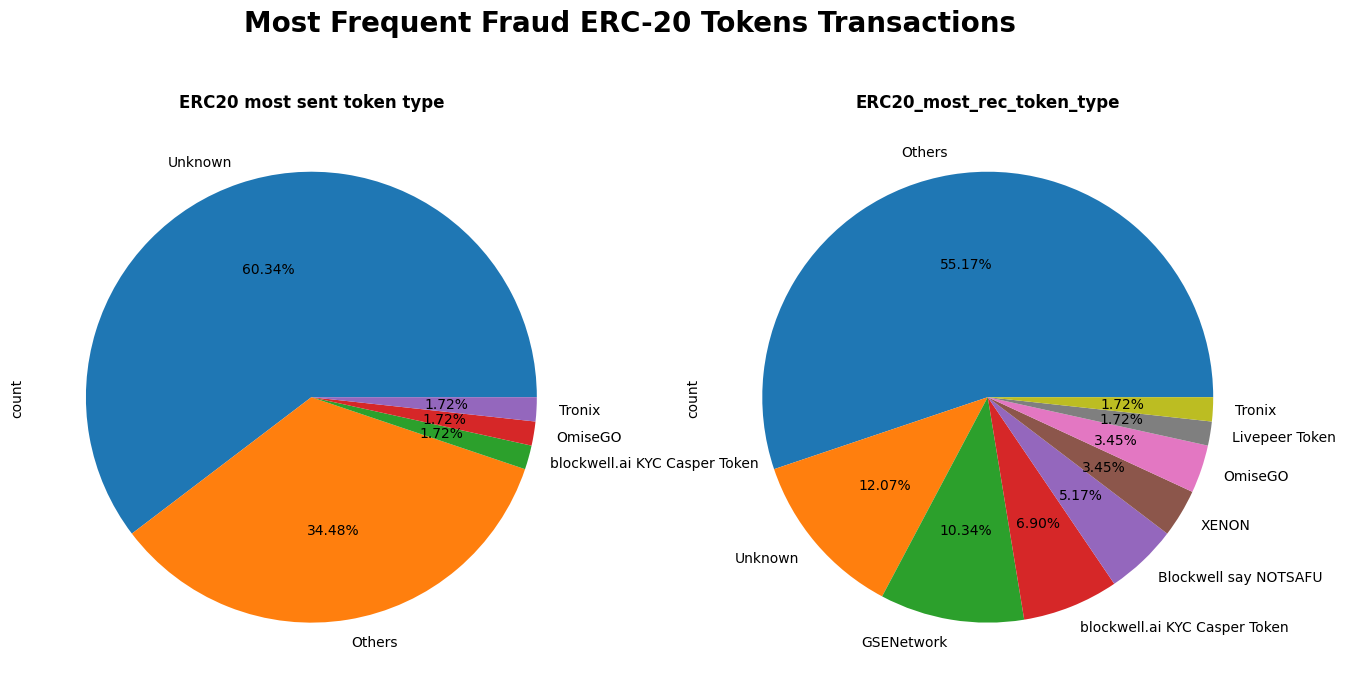

In [83]:
# Categorical columns
filtered_temp = test_temp[(test_temp['FLAG']==1) & (test_temp['pred_test']==0)]

# Plot
fig, ax = plt.subplots(1,2, figsize=(16,8))
plt.suptitle('Most Frequent Fraud ERC-20 Tokens Transactions', fontsize=20, fontweight='bold')
n=0
for i in cat_cols:
    filtered_temp[i].value_counts().plot(kind='pie', autopct='%.2f%%', ax=ax[n]).set_title(i, fontweight='bold')
    n+=1

***Disadvantages:***

- This model has a poor perfromance in predicting data with:
    * higher transaction value (≥ 12 ETH), 
    * higher frequency trades (≤ 50 trx for ETH and ≤ 60trx for ERC-20 tokens)
    * new wallets (< 3 months)
    * ERC-20 tokens trx between 1-4x
    * Unfamous ERC-20 tokens transaction ('Others' & 'Unkown')

- Most token names may not be relevant in today's era since many altcoins have gone unnoticed in the following cycle

- The ETH amount predicted may not be accurate in today's era since the ETH price has surged significantly and higher gas fee

- This model is limited to predict fraudlent cases based on the wallet address historical transaction, rather than the exact transaction hash on Ethereum chain

- Slightly biased towards the dominant categories

- Tend to overfit

---

In [85]:
# Filter TP (true positive) data only
test_temp[(test_temp['FLAG']==1) & (test_temp['pred_test']==1)].describe()

,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,avg val received,min val sent,max val sent,avg val sent,total transactions (including tnx to create contract,total Ether sent,total ether received,total ether balance,Total ERC20 tnxs,ERC20 total Ether received,ERC20 uniq rec addr,ERC20 uniq rec contract addr,ERC20 max val rec,ERC20 avg val rec,ERC20 uniq rec token name,FLAG,pred_test
count,596.000000,596.00000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,5.960000e+02,596.000000,596.000000,5.960000e+02,5.960000e+02,596.000000,596.0,596.0
mean,2606.027785,46250.28302,4.067114,11.390940,9.102349,2.647651,0.192698,5.149171,0.994662,3.010866,12.180712,4.571136,15.540268,20.747934,18.786718,-1.961216,3.442953,6.003742e+05,2.095638,2.078859,3.018882e+05,1.031451e+04,2.068792,1.0,1.0
std,8926.561423,90822.25766,14.546900,38.314091,28.155832,8.506844,0.583813,19.299407,2.725265,8.306604,58.110949,11.511966,47.525951,107.393630,98.093506,40.914978,17.520171,1.251316e+07,6.745001,6.723006,6.261228e+06,1.524053e+05,6.651743,0.0,0.0
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-985.850000,1.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.0,1.0
25%,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9.555000e-13,1.000000,1.000000,0.000000e+00,0.000000e+00,1.000000,1.0,1.0
50%,59.725000,6274.12000,1.000000,2.000000,2.000000,1.000000,0.003574,0.595000,0.438446,0.009927,0.653634,0.454000,4.000000,0.988364,1.000000,0.000483,1.000000,1.337000e+00,1.000000,1.000000,1.337000e+00,1.337000e+00,1.000000,1.0,1.0
75%,609.537500,42760.27250,2.000000,9.000000,7.000000,2.000000,0.126250,3.664945,1.000000,1.516018,6.782987,3.852470,12.000000,9.707275,9.981138,0.002020,1.000000,1.337000e+01,1.000000,1.000000,1.337000e+01,1.337000e+01,1.000000,1.0,1.0
max,96705.400000,525952.00000,221.000000,570.000000,471.000000,99.000000,10.000000,236.061489,34.000000,87.096356,1084.500000,123.250000,681.000000,1835.170056,1835.176671,58.101399,195.000000,3.023666e+08,76.000000,86.000000,1.512722e+08,2.913102e+06,84.000000,1.0,1.0


Characteristics based on Q2(50%) and Q3(50%) values:

- `Avg min between received tnx` 59.7 minutes (1 hr)

- `Time Diff between first and last (Mins)` 6,274 min. - 42,760 min. (4 days - 30 days)
- `Sent Tnx` 1 - 2x
- `Received Tnx` 2 - 9x
- `Unique Received From Addresses` 2 - 7 unique address
- `Unique Sent to Addresses` 1 - 2 unique address
- `max value received` 0.6 - 3.66 ETH
- `max val sent` 0.65 - 6.78 ETH
- `total transactions (including tnx to create contract` 4-12x (cummulative trx)
- `total Ether sent` 0.98 - 9.7 ETH 
- `total Ether received` 1 - 9.98 ETH
- `total ether balance` 0.0005 - 0.002 ETH
- `Total ERC20 tnxs` 1x 
- `ERC20 total Ether received` 1.337 - 13.37 ETH equiv
- `ERC20 uniq rec addr` & `ERC20 uniq rec contract addr` 1 unique address 
- `ERC20 max val rec` 1.337 - 13.37 ETH
- `ERC20 uniq rec token name` 1 token name

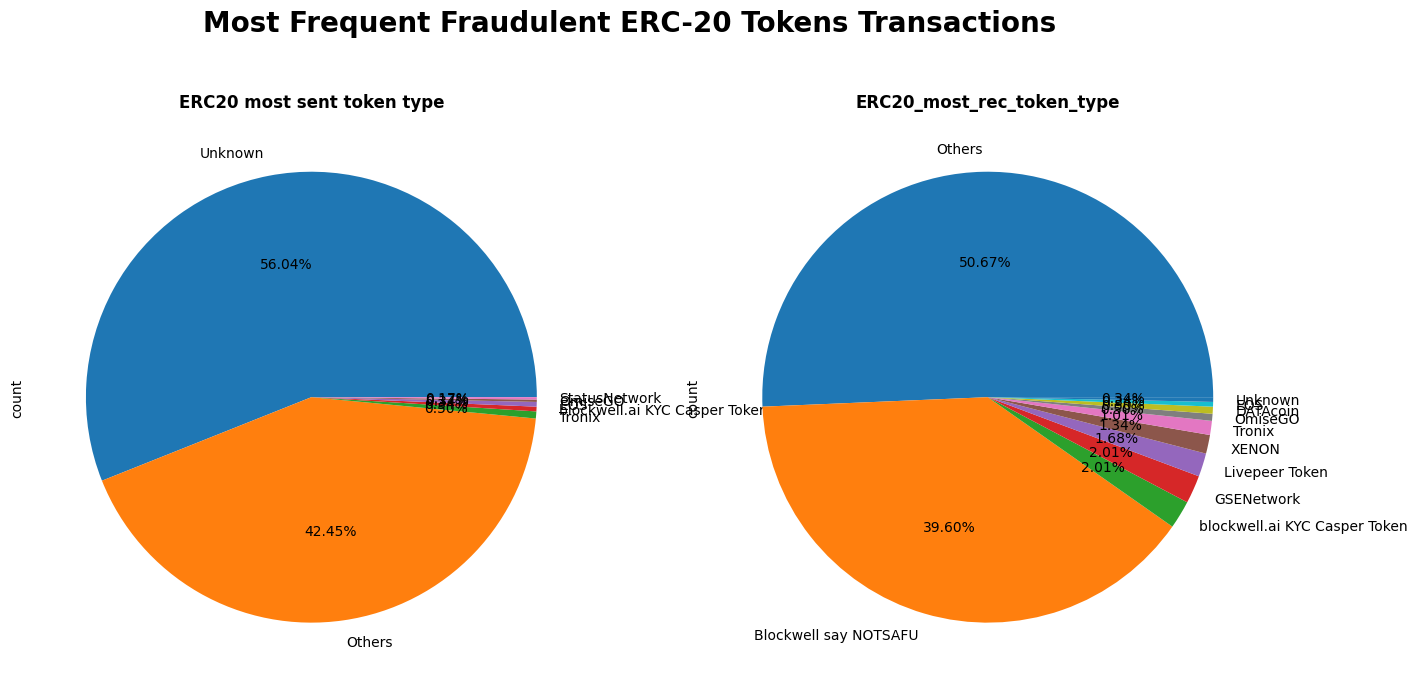

In [87]:
# Categorical columns
filtered_temp2 = test_temp[(test_temp['FLAG']==1) & (test_temp['pred_test']==1)]

# Plot
fig, ax = plt.subplots(1,2, figsize=(16,8))
plt.suptitle('Most Frequent Fraudulent ERC-20 Tokens Transactions', fontsize=20, fontweight='bold')
n=0
for i in cat_cols:
    filtered_temp2[i].value_counts().plot(kind='pie', autopct='%.2f%%', ax=ax[n]).set_title(i, fontweight='bold')
    n+=1

***Advantages:***

- This model predicts accurately when suspicious behaviour occurs, such as:
    * new wallets (< 1 month old) that recieved transaction every 1 hour or quicker than that
    * have made 4-12x transaction:
        * `SENT` transactions to 1-2 unique addresses only, but
        * `RECEIVED` transactions from 2-7 unique addresses 
    * average ETH transaction value < 10 ETH
    * near zero balance (0.0005 - 0.002 ETH)
    * Only 1x cummulative ERC 20 transaction recorded (either `SENT` only or `RECEIVED` only)
    * mostly from unpopular ERC-20 tokens (`Others`) transaction records and `unknown` ERC-20 Token name (might have been banned / delisted)
    * `Received` tokens from some popular tokens such as, Blockwell say NOTSAFU, blockwell Casper Token, GSENetwork, Livepeer Token, and XENON

- Performs well in high-dimensionality data & fast training time

In [88]:
# AUC Score
y_pred_proba = pipe_xgb.predict_proba(X_test)[:,1]
auc_xgb = roc_auc_score(y_test, y_pred_proba)

print("AUC Score:", auc_xgb)

AUC Score: 0.9623995246802195


AUC Score > 0.9 is quite impressive  means the model can distinguish between classes really well.

In [89]:
# Create function to create reports
def eval_recap(final_recap, y_train, y_pred_train, y_test, y_pred_test, y_pred_proba, name):
    # Calculate recall scores & AUC Score
    score_reports = {
        'AUC Score': roc_auc_score(y_test, y_pred_proba),
        'Recall Train Set': recall_score(y_train, y_pred_train),
        'Recall Test Set': recall_score(y_test, y_pred_test),
    }

    # Calculate confusion matrices for train and test sets
    cm_train = confusion_matrix(y_train, y_pred_train)
    cm_test = confusion_matrix(y_test, y_pred_test)

    # Extract false negatives from the confusion matrices and add to the report
    score_reports['False Negative Train'] = cm_train[1, 0]
    score_reports['False Negative Test'] = cm_test[1, 0]

    # Store the report in the dictionary with the specified model name
    final_recap[name] = score_reports
    return final_recap

final_report = {}
final_report = eval_recap(final_report, y_train, y_pred_train, y_test, y_pred_test, y_pred_proba, 'XGB before Tuning')

pd.DataFrame(final_report)

,XGB before Tuning
AUC Score,0.962400
Recall Train Set,1.000000
Recall Test Set,0.911315
False Negative Train,0.000000
False Negative Test,58.000000


## **Hyperparameter Tuning**

Since the default model of XGBoost Classifier is a tree-based model, hence the paremeter tuning that will be used are :

- `max_depth` = higher tree depth, leads to an overfit model

- `min_child_weight` =  number of total weighted data to be trained for the next model, higher `min_child_weight` --> Less overfit
- `gamma` = same concept as in SVM, higher value will make the model more conservative
- `colsample_bytree` = similar to `max_features` in decision tree, lower value --> more underfit

In this case, `RandomizedSearchCV` algorithm will be used to find the best parameter in hypertuning process due to lower model size, faster computing time, & comparable result with `GridSearchCV`.

In [90]:
# Parameter tuning
params = {'xgbclassifier__max_depth': [2,3,4],
              'xgbclassifier__min_child_weight':[20, 30, 40, 50],
              'xgbclassifier__gamma': [0.5, 0.6, 0.7, 0.8, 0.9],
              'xgbclassifier__colsample_bytree':[0, 0.2, 0.4, 0.6, 0.8]
              }

rand_search = RandomizedSearchCV(pipe_xgb, param_distributions=params, cv=5, random_state=42)
rand_search.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'xgbclassifier__colsample_bytree': [0, 0.2, ...], 'xgbclassifier__gamma': [0.5, 0.6, ...], 'xgbclassifier__max_depth': [2, 3, ...], 'xgbclassifier__min_child_weight': [20, 30, ...]}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [91]:
# Best Hyperparamters & Score
print('Best Hyperparameters:', rand_search.best_params_)
print('Best Recall Score:', rand_search.best_score_)

# Best Hyperparamters & Score
best_xgb = rand_search.best_estimator_

Best Hyperparameters: {'xgbclassifier__min_child_weight': 20, 'xgbclassifier__max_depth': 3, 'xgbclassifier__gamma': 0.6, 'xgbclassifier__colsample_bytree': 0.6}
Best Recall Score: 0.9662295081967212


After parameter tuning, the Train set Recall Score has dropped slightly to 0.96, with the following parameters:

- `colsample_bytree` = 0.6
- `gamma` = 0.6
- `min_child_weight` = 20
- `max_depth` = 3

## **Hyperparameter Evaluation**

In [92]:
# Predict data
y_pred_train_tuned = best_xgb.predict(X_train)
y_pred_test_tuned = best_xgb.predict(X_test)

# Best Hyperparamters & Score
print('Train Recall (Tuned):', recall_score(y_train, y_pred_train_tuned))
print('Test Recall (Tuned):', recall_score(y_test, y_pred_test_tuned))

Train Recall (Tuned): 0.9777049180327869
Test Recall (Tuned): 0.900611620795107


After hyperparameter tuning, the gap between Train & Test recall scores has decreased from 8.87% (before tuning) to 7.77%. Although this model shows a slight improvement, the difference remains higher than 5%, indicating an overfit model.

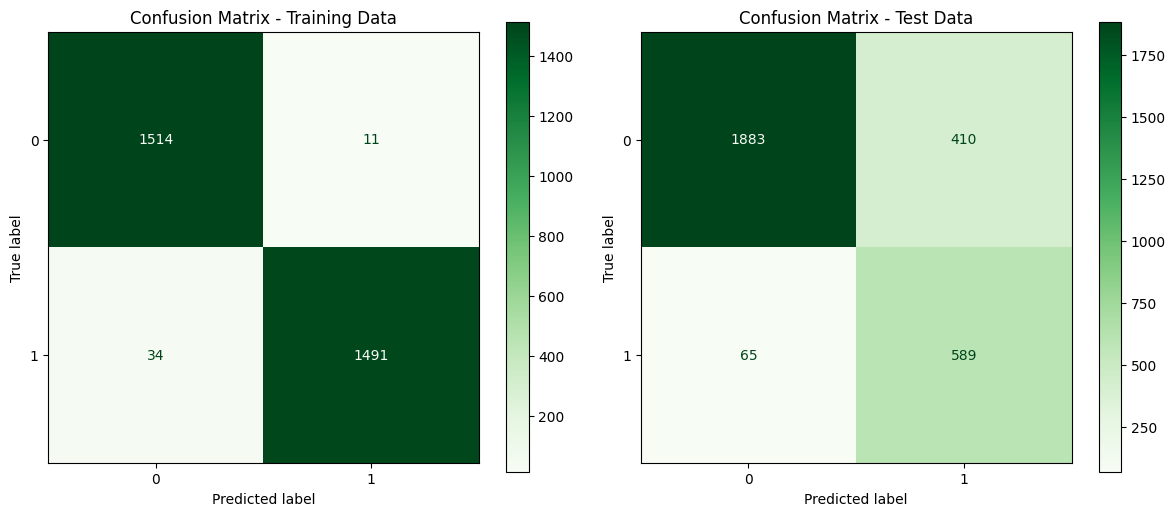

In [93]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot confusion matrix for training data
train_matrix = ConfusionMatrixDisplay.from_estimator(best_xgb, X_train, y_train, cmap='Greens',ax=axes[0])
train_matrix.ax_.set_title('Confusion Matrix - Training Data')

# Plot confusion matrix for test data
test_matrix = ConfusionMatrixDisplay.from_estimator(best_xgb, X_test, y_test, cmap='Greens',ax=axes[1])
test_matrix.ax_.set_title('Confusion Matrix - Test Data')

plt.tight_layout()
plt.show()

The FN value in both Train & Test data slightly increase due to lower Recall scores, but this is still better than the previous one, indicating this model is less overfit.

In [94]:
# AUC Score
y_pred_tuned_proba = best_xgb.predict_proba(X_test)[:,1]
auc_xgb_tuned = roc_auc_score(y_test, y_pred_tuned_proba)

print("AUC Score:", auc_xgb_tuned)

AUC Score: 0.9552537239384324


AUC Score also reduced slightly, but still indicating the model can distinguish 2 classes properly.

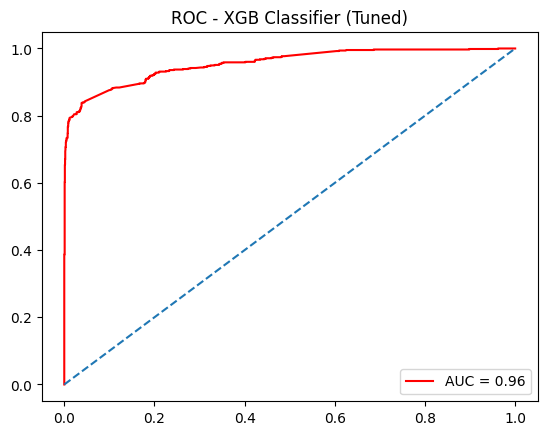

In [95]:
# ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_tuned_proba)

plt.title('ROC - XGB Classifier (Tuned)')
plt.plot(fpr, tpr, 'r', label = 'AUC = %0.2f' % auc_xgb_tuned)
plt.legend(loc = 'lower right')
plt.plot([0,1], [0,1], linestyle = '--')
plt.show()

In [96]:
# Update to recap table
final_report = eval_recap(final_report, y_train, y_pred_train_tuned, y_test, y_pred_test_tuned, y_pred_tuned_proba, 'XGB after Tuning')
pd.DataFrame(final_report)

,XGB before Tuning,XGB after Tuning
AUC Score,0.962400,0.955254
Recall Train Set,1.000000,0.977705
Recall Test Set,0.911315,0.900612
False Negative Train,0.000000,34.000000
False Negative Test,58.000000,65.000000


Best model for inferencing new data is XGB after tuning because the model is slightly less overfit than the original model & still performs quite a

In [97]:
# Correlation check
final_concat = pd.concat([X_train, y_train], axis=1)
phik_corr(final_concat, final_concat.columns, 'FLAG').sort_values(ascending=False)

interval columns not set, guessing: ['Avg min between received tnx', 'Time Diff between first and last (Mins)', 'Sent tnx', 'Received Tnx', 'Unique Received From Addresses', 'Unique Sent To Addresses', 'min value received', 'max value received', 'avg val received', 'min val sent', 'max val sent', 'avg val sent', 'total transactions (including tnx to create contract', 'total Ether sent', 'total ether received', 'total ether balance', 'Total ERC20 tnxs', 'ERC20 total Ether received', 'ERC20 uniq rec addr', 'ERC20 uniq rec contract addr', 'ERC20 max val rec', 'ERC20 avg val rec', 'ERC20 uniq rec token name', 'FLAG']


FLAG                                                    1.000000
ERC20_most_rec_token_type                               0.942963
Total ERC20 tnxs                                        0.772322
ERC20 uniq rec addr                                     0.749906
ERC20 uniq rec contract addr                            0.748490
ERC20 uniq rec token name                               0.748389
total ether received                                    0.653470
total Ether sent                                        0.603095
avg val received                                        0.586918
max value received                                      0.568603
min value received                                      0.519633
Time Diff between first and last (Mins)                 0.514827
max val sent                                            0.502976
Unique Sent To Addresses                                0.441260
avg val sent                                            0.440870
total transactions (inclu

After tuning, the correlation between each feature & column have increased. `ERC20_most_rec_token_type`, `Total ERC20 tnxs`, `ERC20 uniq rec addr`, `ERC20 uniq rec contract addr`, and `ERC20 uniq rec token name` are the top 5 most influential columns with strong correlation towards the feature since all values are above 0.7.


# **IX. MODEL SAVING**

In [ ]:
# Save the best model
with open('best_xgb.pkl', 'wb') as model_file:
  pickle.dump(best_xgb, model_file)

# **X. MODEL INFERENCE**

Different Notebook

# **XI. CONCLUSION**

***Summary:***

* On average, each wallet address may receive between 43.8 ETH - 523.7 ETH and sent between 4.8 ETH - 314.5 ETH in a single transaction every 4-6 days.

* Most users have spent 10,178 ETH and received 11,658 ETH cummulatively

* Average total ERC-20 token received and sent per wallet address are 129.8 million ETH and 13.9 million ETH, respectively

*  The model can predict suspicious account that's only been active for < 1 month, transacted < 10 ETH (sent to ≤ 2 unique addresses and received from ≤ 7 unique addresses), having 4-12 ETH trx and near zero balance, mainly send and receive unpopular and unknown ERC-20 tokens, as well as some popular tokens such as Blockwell say NOTSAFU, blockwell Casper Token, GSENetwork, Livepeer Token, and XENON from other wallets to realized the dirty money & convert it to fiat currencies.

* The model may not perform well in detecting new wallets that's been active for ≤ 3 months, higher transaction value (≥ 12 ETH) (sent to ≤ 2 unique addresses and received from ≤ 23 unique addresses), higher frequency trades (≤ 50 ETH trx & ≤ 4 ERC-20 trx), traded unpopular ('Other') and 'Unknown' tokens

* This model is limited to predict fraud transactions based on the wallet address, instead of the real transaction hash

* Most token names may not be relevant in today's era since many altcoins have gone unnoticed in the following cycle
    
***Business Recommendation:***

* CEXs and DEXs team may consider to raise the minimum required threshold for token listing based on the market cap, tokenomics, average volume trades and collaborate with blockchain security services, like CertiK to verify each token before listing

* Delisting suspicious tokens that are popular or prone to have fraudulent transactions quickly

* Fraudulent wallet addresses should be banned permanently 

* Block fraud users to create new wallet address by limiting their device or their IP Address

* Provide a user-friendly wallet address prediction / detectors menu for CEX / DEX users before verifying a transaction


***Model Imporvement:***
* Try using `SMOTE` or a combination of `SMOTE` & Random Undersampling to handle imbalanced data

* Try `test_size = 0.4` in `train_test_split` to reduce overfit

* Might rely on PCA alone during feature selection, instead of manually removing uncorrelated columns to reduce overfit probability

* Reduce cardinality features to 15-20 groups per column to prevent overfit

* Train more data to validate the model consistency & accuracy
